# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 26 - 4to bimestre 2026

## **Alumno 1:** Lerner, Federico Ezequiel - a2619

## **Alumno 2:** Makk, Azul de los Angeles - a2622

## **Alumno 3:** Moguilner Reh, Nicolás Francisco - a2623

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 18 de septiembre (hora de Argentina)**.

La resolución del TP puede realizarse de forma **individual, en parejas o hasta en grupos de 3 como máximo**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que todos los integrantes deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local (posteriormente deben subirlo a Google Drive). Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/HRfmzTPcM1yyMWw86)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERAPELLIDOALUMNO3-TP1-Co26.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co26.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros que se busca optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado), acotada de -1 a 1 en el eje vertical. Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### Elección del dataset sintético

La consigna pide un patrón no lineal acotado entre -1 y 1, que no sea una `tanh` sola y que no sea tan complejo como para que una red de una sola conexión no pueda converger. Buscamos un equilibrio entre dos cosas:

1. **Que el modelo pueda capturar algo no lineal.** $\hat y = \tanh(wx+b)$ solo puede generar curvas monótonas con forma de "S". Si el patrón no tiene una tendencia dominante de ese tipo (por ejemplo un seno con más de un período en el rango), el mejor ajuste posible termina siendo casi una recta con pendiente chica y el modelo no aprende nada interesante.
2. **Que quede un error que el modelo no pueda eliminar**, para que la comparación de optimizadores no sea trivial.

Por eso combinamos tres componentes:

$$f(x) = 0.55\,\sin(1.1x) + 0.35\,\tanh\!\left(\tfrac{x^3}{3}\right) + 0.1\,\cos(5x)$$

- $0.55\sin(1.1x)$ y $0.35\tanh(x^3/3)$ juntas dan una tendencia creciente con forma de "S", pero **no** son una `tanh` pura: el seno aporta curvatura propia, la cúbica dentro de la `tanh` cambia la forma de la transición, y la suma **no es monótona** (tiene extremos locales en $x \approx \pm 1.7$).
- $0.1\cos(5x)$ agrega una ondulación de alta frecuencia que una neurona monótona tampoco puede seguir.

Esas dos propiedades son las que dejan el error irreducible. Ajustando la mejor `tanh` posible a cada versión del patrón se puede medir cuánto pesa cada una: contra la parte principal sola el MSE mínimo ya es 0.0121, agregando el coseno sube a 0.0171, y sumando el ruido llega a 0.0189, que es el piso $J^*$ que aparece en 1c. O sea que la mayor parte del error irreducible viene de que el patrón principal no es monótono, y el coseno y el ruido aportan el resto.

Usamos `x = np.linspace(-2.5, 2.5, 300)` (rango simétrico, $n=300 \geq 200$) y ruido gaussiano con $\sigma=0.05$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (habilita projection="3d")

%matplotlib inline

n = 300 | x en [-2.5, 2.5] | y en [-0.969, 0.979] | var(y) = 0.3973


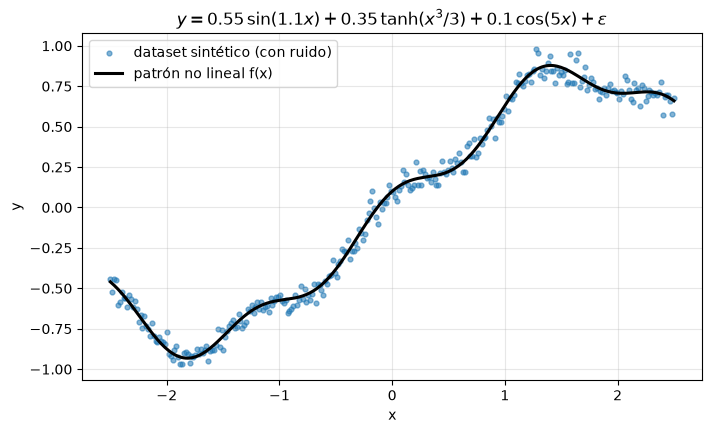

In [2]:
N = 300
INI, FIN = -2.5, 2.5
x = np.linspace(INI, FIN, N)

def f_no_lineal(x):
    return 0.55 * np.sin(1.1 * x) + 0.35 * np.tanh(x**3 / 3) + 0.1 * np.cos(5 * x)

rng = np.random.default_rng(42)
ruido = rng.normal(0, 0.05, size=N)
y = f_no_lineal(x) + ruido

print(f"n = {N} | x en [{x.min()}, {x.max()}] | y en [{y.min():.3f}, {y.max():.3f}] | var(y) = {y.var():.4f}")

plt.figure(figsize=(8, 4.5))
plt.scatter(x, y, s=12, alpha=0.55, label="dataset sintético (con ruido)")
plt.plot(x, f_no_lineal(x), color="black", lw=2.2, label="patrón no lineal f(x)")
plt.xlabel("x"); plt.ylabel("y")
plt.title(r"$y = 0.55\,\sin(1.1x) + 0.35\,\tanh(x^3/3) + 0.1\,\cos(5x) + \varepsilon$")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [3]:
def forward(w, b, x):
    z = w * x + b
    return np.tanh(z)

def costo(w, b, x, y):
    return np.mean((forward(w, b, x) - y) ** 2)

def gradientes(w, b, x, y):
    # Regla de la cadena (clase 2):
    #   dJ/dw = dJ/dyhat * dyhat/dz * dz/dw
    #   dJ/dyhat = (2/m)(yhat - y)     dyhat/dz = 1 - tanh(z)^2     dz/dw = x     dz/db = 1
    m = x.shape[0]
    yhat = forward(w, b, x)
    delta = (2.0 / m) * (yhat - y) * (1 - yhat ** 2)   # error imputado a la neurona (dJ/dz)
    return np.sum(delta * x), np.sum(delta)

# Chequeo de las derivadas contra diferencias finitas en un punto cualquiera
h = 1e-6
dw_an, db_an = gradientes(0.7, -0.3, x, y)
dw_num = (costo(0.7 + h, -0.3, x, y) - costo(0.7 - h, -0.3, x, y)) / (2 * h)
db_num = (costo(0.7, -0.3 + h, x, y) - costo(0.7, -0.3 - h, x, y)) / (2 * h)
print(f"dJ/dw analítica={dw_an:.6f}  numérica={dw_num:.6f}")
print(f"dJ/db analítica={db_an:.6f}  numérica={db_num:.6f}")

# Inicialización aleatoria con np.random.randn(). Se usa la MISMA para GD y para Adam (1b).
np.random.seed(3)
w0, b0 = np.random.randn(), np.random.randn()
print(f"\nInicialización: w0 = {w0:.4f}, b0 = {b0:.4f}  ->  J(w0, b0) = {costo(w0, b0, x, y):.4f}")

EPOCHS = 100
LRS = [0.1, 0.01, 0.001]
COLORES_LR = {0.1: "tab:red", 0.01: "tab:blue", 0.001: "tab:green"}

dJ/dw analítica=-0.032930  numérica=-0.032930
dJ/db analítica=-0.212476  numérica=-0.212476

Inicialización: w0 = 1.7886, b0 = 0.4365  ->  J(w0, b0) = 0.1053


**Sobre la inicialización.** $w_0$ y $b_0$ salen de `np.random.randn()`; la semilla solo está fijada para que los resultados sean reproducibles. Con la semilla 3 queda $w_0 \approx 1.79$, $b_0 \approx 0.44$, bastante lejos del mínimo ($w^* \approx 0.63$, $b^* \approx 0$, calculado en 1c): la `tanh` arranca con una pendiente casi tres veces más empinada que la óptima. Con semillas cuyo punto inicial cae muy cerca del mínimo, los tres optimizadores convergen casi igual y la comparación pierde información, así que preferimos una inicialización que obligue a recorrer una distancia apreciable en el espacio de parámetros. Para no depender de esa elección, en 1c repetimos todos los entrenamientos con 20 semillas distintas y verificamos que las conclusiones se mantienen. La distancia al mínimo de la semilla 3 (1.24) es, de hecho, muy parecida a la mediana de esas 20 inicializaciones (1.16).

La verificación de arriba compara las derivadas analíticas (regla de la cadena) contra diferencias finitas y coinciden, así que el gradiente que usan los tres optimizadores está bien calculado.

GD  lr=0.1    J inicial=0.1053  J final=0.0539  w=1.2034  b=0.0561
GD  lr=0.01   J inicial=0.1053  J final=0.0999  w=1.7471  b=0.3756
GD  lr=0.001  J inicial=0.1053  J final=0.1048  w=1.7847  b=0.4301


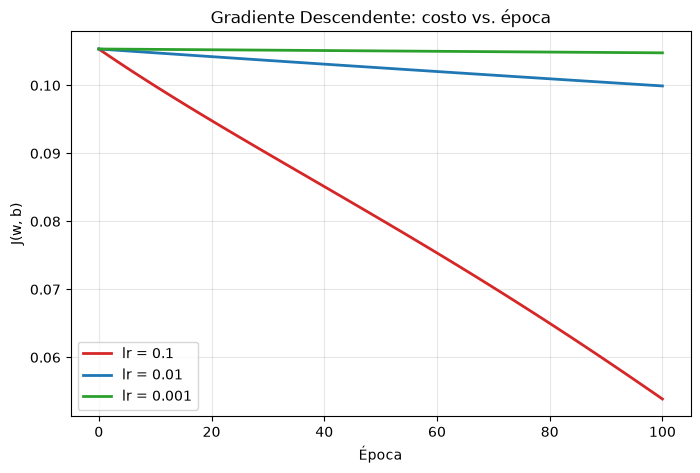

In [4]:
def gradiente_descendente(lr, epochs=EPOCHS):
    w, b = w0, b0
    hist_w, hist_b, hist_J = [w], [b], [costo(w, b, x, y)]   # posición 0 = punto inicial
    for _ in range(epochs):
        dw, db = gradientes(w, b, x, y)    # gradiente con TODO el dataset -> 1 actualización por época
        w = w - lr * dw
        b = b - lr * db
        hist_w.append(w); hist_b.append(b); hist_J.append(costo(w, b, x, y))
    return {"w": np.array(hist_w), "b": np.array(hist_b), "J": np.array(hist_J),
            "w_upd": np.array(hist_w), "b_upd": np.array(hist_b), "J_upd": np.array(hist_J)}

gd_hist = {lr: gradiente_descendente(lr) for lr in LRS}
for lr in LRS:
    h_ = gd_hist[lr]
    print(f"GD  lr={lr:<6} J inicial={h_['J'][0]:.4f}  J final={h_['J'][-1]:.4f}  w={h_['w'][-1]:.4f}  b={h_['b'][-1]:.4f}")

# --- fin de la lógica de GD, de acá para abajo es solo para graficar ---
plt.figure(figsize=(8, 5))
for lr in LRS:
    plt.plot(gd_hist[lr]["J"], label=f"lr = {lr}", color=COLORES_LR[lr], linewidth=2)
plt.xlabel("Época"); plt.ylabel("J(w, b)")
plt.title("Gradiente Descendente: costo vs. época")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Con 100 épocas, GD no llega al mínimo con ninguno de los tres learning rates:

- `lr=0.1`: el costo baja de 0.105 a 0.054 casi en línea recta y sigue bajando al final. Le falta mucho: el mínimo es $J^* \approx 0.019$ (ver 1c).
- `lr=0.01` y `lr=0.001`: prácticamente no se mueve (0.100 y 0.105).

El motivo es cuantitativo. Sobre la trayectoria de GD la norma del gradiente se mantiene casi constante, alrededor de $|\nabla J| \approx 0.07$ (lo medimos en 1d). Como el paso de GD es $\eta\,|\nabla J|$, con `lr=0.1` cada actualización mueve los parámetros unas 0.0072 unidades, y en 100 épocas la distancia máxima que puede recorrer es ≈0.72. La distancia en línea recta entre el punto inicial y el mínimo es ≈1.24, así que aunque avance en la dirección perfecta **no le alcanzan las épocas**. Con `lr=0.01` y `lr=0.001` el paso es 10 y 100 veces más chico. Que la curva sea casi una recta también se explica por esto: el gradiente es casi constante, entonces cada época baja más o menos lo mismo.

El problema no es que GD esté mal implementado o que la superficie tenga un mínimo local que lo atrape, sino que su paso depende directamente de la magnitud del gradiente, y en esta superficie esa magnitud es chica.

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno full-batch y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

Adam (Kingma & Ba, 2014; visto en la clase 2) mantiene, para cada parámetro, un promedio móvil del gradiente ($m_t$, momento de 1er orden) y de su cuadrado ($v_t$, momento de 2do orden), les corrige el sesgo inicial y actualiza con $\theta_t = \theta_{t-1} - \eta\, \hat m_t / (\sqrt{\hat v_t} + \epsilon)$. Usamos los valores por defecto $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$.

- **Full-batch:** el gradiente se calcula con las 300 muestras → 1 actualización por época (100 en total).
- **Mini-batch:** en cada época se barajan las muestras y se recorren en lotes de `BATCH_SIZE = 30` → 10 actualizaciones por época (1000 en total). Elegimos 30 porque divide exacto a 300: así ningún lote queda con menos de 16 muestras.

En ambos casos el costo que se grafica por época es el **costo sobre el dataset completo**, para que sea comparable contra GD y contra full-batch (el costo de un mini-batch individual es una estimación ruidosa).

Adam full-batch  lr=0.1    J final=0.0189  w=0.6297  b=-0.0031  (actualizaciones: 100)
Adam full-batch  lr=0.01   J final=0.0202  w=0.7047  b=-0.0022  (actualizaciones: 100)
Adam full-batch  lr=0.001  J final=0.0950  w=1.6853  b=0.3390  (actualizaciones: 100)
Adam mini-batch  lr=0.1    J final=0.0189  w=0.6165  b=-0.0083  (actualizaciones: 1000)
Adam mini-batch  lr=0.01   J final=0.0189  w=0.6277  b=-0.0031  (actualizaciones: 1000)
Adam mini-batch  lr=0.001  J final=0.0208  w=0.7223  b=-0.0040  (actualizaciones: 1000)


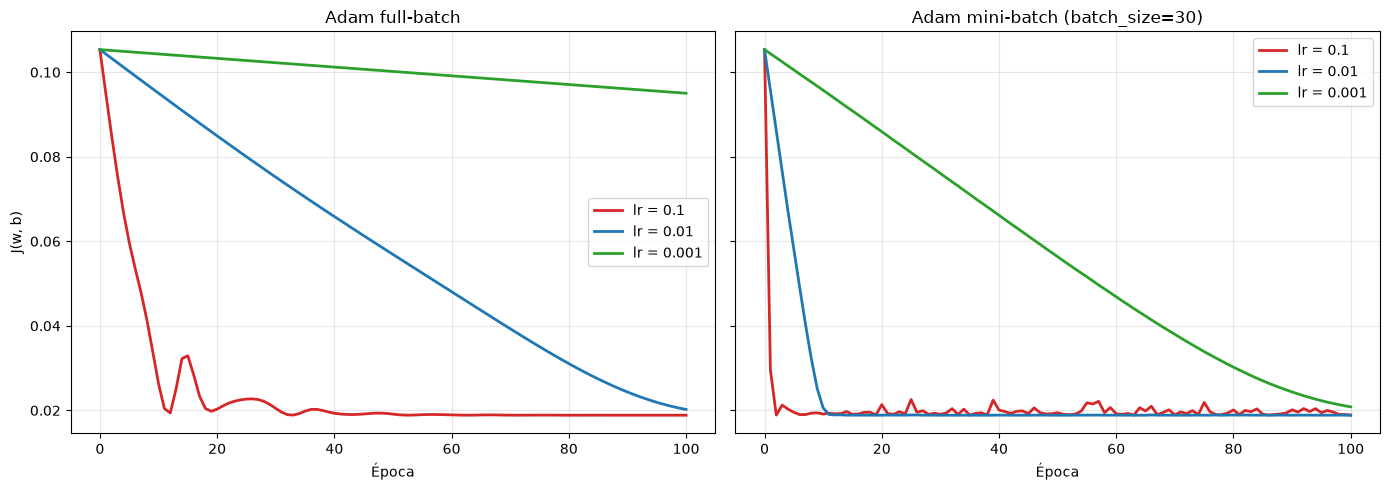

In [5]:
BETA1, BETA2, EPS = 0.9, 0.999, 1e-8
BATCH_SIZE = 30

def paso_adam(theta, grad, m, v, t, lr):
    m = BETA1 * m + (1 - BETA1) * grad            # momento de 1er orden
    v = BETA2 * v + (1 - BETA2) * grad ** 2       # momento de 2do orden
    m_hat = m / (1 - BETA1 ** t)                  # corrección de sesgo
    v_hat = v / (1 - BETA2 ** t)
    theta = theta - lr * m_hat / (np.sqrt(v_hat) + EPS)
    return theta, m, v

def adam_full_batch(lr, epochs=EPOCHS):
    theta = np.array([w0, b0])                    # theta = [w, b]
    m, v, t = np.zeros(2), np.zeros(2), 0
    hist = [theta.copy()]
    for _ in range(epochs):
        t += 1
        grad = np.array(gradientes(theta[0], theta[1], x, y))   # todo el dataset
        theta, m, v = paso_adam(theta, grad, m, v, t, lr)
        hist.append(theta.copy())
    hist = np.array(hist)
    J = np.array([costo(wi, bi, x, y) for wi, bi in hist])
    return {"w": hist[:, 0], "b": hist[:, 1], "J": J, "w_upd": hist[:, 0], "b_upd": hist[:, 1], "J_upd": J}

def adam_mini_batch(lr, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=0):
    rng_mb = np.random.default_rng(seed)
    theta = np.array([w0, b0])
    m, v, t = np.zeros(2), np.zeros(2), 0
    hist_epoca, hist_upd = [theta.copy()], [theta.copy()]
    for _ in range(epochs):
        perm = rng_mb.permutation(N)              # se baraja en cada época
        for inicio in range(0, N, batch_size):
            idx = perm[inicio:inicio + batch_size]
            t += 1
            grad = np.array(gradientes(theta[0], theta[1], x[idx], y[idx]))   # solo el lote
            theta, m, v = paso_adam(theta, grad, m, v, t, lr)
            hist_upd.append(theta.copy())
        hist_epoca.append(theta.copy())
    hist_epoca, hist_upd = np.array(hist_epoca), np.array(hist_upd)
    return {"w": hist_epoca[:, 0], "b": hist_epoca[:, 1],
            "J": np.array([costo(wi, bi, x, y) for wi, bi in hist_epoca]),
            "w_upd": hist_upd[:, 0], "b_upd": hist_upd[:, 1],
            "J_upd": np.array([costo(wi, bi, x, y) for wi, bi in hist_upd])}

adam_fb_hist = {lr: adam_full_batch(lr) for lr in LRS}
adam_mb_hist = {lr: adam_mini_batch(lr) for lr in LRS}
for nombre, hist in [("Adam full-batch", adam_fb_hist), ("Adam mini-batch", adam_mb_hist)]:
    for lr in LRS:
        h_ = hist[lr]
        print(f"{nombre}  lr={lr:<6} J final={h_['J'][-1]:.4f}  w={h_['w'][-1]:.4f}  b={h_['b'][-1]:.4f}  (actualizaciones: {len(h_['J_upd']) - 1})")

# --- fin de la lógica de Adam, de acá para abajo es solo para graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (titulo, hist) in zip(axes, [("Adam full-batch", adam_fb_hist), (f"Adam mini-batch (batch_size={BATCH_SIZE})", adam_mb_hist)]):
    for lr in LRS:
        ax.plot(hist[lr]["J"], label=f"lr = {lr}", color=COLORES_LR[lr], linewidth=2)
    ax.set_title(titulo); ax.set_xlabel("Época"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("J(w, b)")
plt.tight_layout(); plt.show()

**Adam full-batch.** Con `lr=0.1` converge rápido: cruza el umbral de 5% sobre $J^*$ en la época 12. Pero no baja de forma monótona: en la época 15 el costo rebota hasta 0.033 y después sigue con oscilaciones amortiguadas (34 épocas en las que $J$ sube, según la tabla de 1c). Es el efecto del momento de primer orden: el promedio $m_t$ acumula la dirección de bajada y sigue empujando aunque ya se haya pasado del mínimo. Con `lr=0.01` la curva es suave y termina en 0.0202, todavía un poco encima del umbral: está terminando de llegar justo en la época 100. Con `lr=0.001` casi no avanza (0.095).

Esto tiene una explicación directa. Cuando el gradiente mantiene el signo y su magnitud no cambia demasiado, $\hat m_t/\sqrt{\hat v_t}$ se mantiene cerca de $\pm 1$ y el paso por parámetro queda del orden de lr, sin importar qué tan chico sea el gradiente. No es una cota general (depende de cómo evolucionen las magnitudes), pero describe bien lo que pasa acá: midiendo aparte el recorrido acumulado de Adam full-batch con `lr=0.01` da 1.23, casi exactamente la distancia de 1.24 que hay que cubrir (la tabla de 1d muestra el equivalente para `lr=0.1`); con `lr=0.001` el recorrido sería unas diez veces menor. Por eso Adam con `lr=0.01` le gana ampliamente a GD con `lr=0.1`: midiendo la norma del paso, GD se mueve 0.0072 por actualización, mientras que Adam da su primer paso de 0.0141 ($\eta\sqrt{2}$, porque avanza ≈lr en cada uno de los dos parámetros) y promedia 0.0123 a lo largo del recorrido, sin tener que "adivinar" la escala del gradiente.

**Adam mini-batch (lotes de 30).** Converge con `lr=0.1` (época 2) y con `lr=0.01` (época 11). Con `lr=0.001` no llega a cruzar el umbral: termina en 0.0208 contra un umbral de 0.0198, aunque queda mucho más cerca del mínimo que las dos versiones full-batch.

La razón principal es que hace 10 actualizaciones por época en vez de 1, o sea 1000 pasos de Adam contra 100. Lo confirmamos en 1c graficando el costo contra la cantidad de actualizaciones: las curvas de full-batch y mini-batch quedan prácticamente superpuestas. El precio del mini-batch se ve con `lr=0.1`: después de converger el costo nunca se estabiliza, sino que queda "temblando" alrededor del mínimo (50 épocas con subidas). Cada gradiente sale de 30 muestras y no de 300, así que tiene ruido, y con un learning rate grande y fijo ese ruido se traduce en pasos grandes alrededor del mínimo.

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

Mínimo de la grilla: w* = 0.63, b* = 0.00, J* = 0.0189
R² del mejor ajuste posible con tanh(wx+b): 0.953


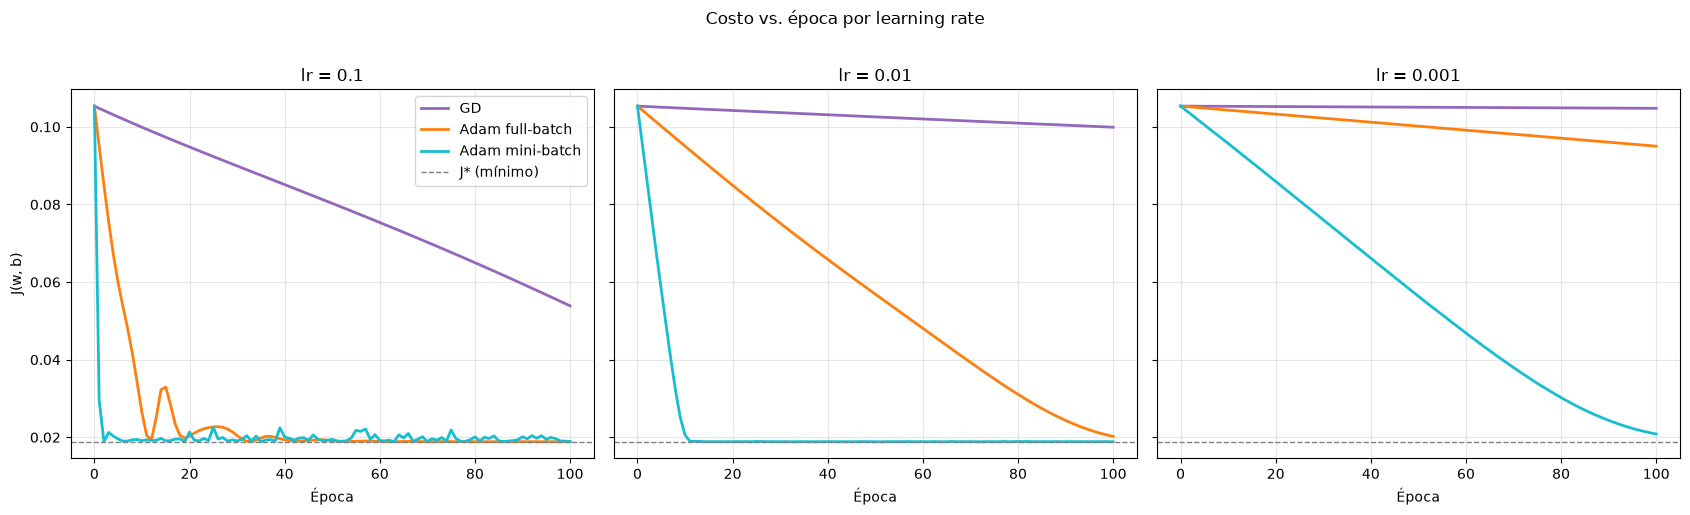

In [6]:
# Referencia: mínimo de J(w, b) por búsqueda exhaustiva en una grilla fina (solo para comparar, no es un optimizador)
w_grid = np.linspace(-4, 4, 801)
b_grid = np.linspace(-2, 2, 401)
J_grid = np.array([[costo(wi, bi, x, y) for wi in w_grid] for bi in b_grid])
i_min, j_min = np.unravel_index(J_grid.argmin(), J_grid.shape)
w_opt, b_opt, J_opt = w_grid[j_min], b_grid[i_min], J_grid[i_min, j_min]
print(f"Mínimo de la grilla: w* = {w_opt:.2f}, b* = {b_opt:.2f}, J* = {J_opt:.4f}")
print(f"R² del mejor ajuste posible con tanh(wx+b): {1 - J_opt / y.var():.3f}")

OPTIMIZADORES = {"GD": gd_hist, "Adam full-batch": adam_fb_hist, "Adam mini-batch": adam_mb_hist}
COLORES_OPT = {"GD": "tab:purple", "Adam full-batch": "tab:orange", "Adam mini-batch": "tab:cyan"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, lr in zip(axes, LRS):
    for nombre, hist in OPTIMIZADORES.items():
        ax.plot(hist[lr]["J"], label=nombre, color=COLORES_OPT[nombre], linewidth=2)
    ax.axhline(J_opt, color="gray", ls="--", lw=1, label="J* (mínimo)")
    ax.set_title(f"lr = {lr}"); ax.set_xlabel("Época"); ax.grid(alpha=0.3)
axes[0].set_ylabel("J(w, b)"); axes[0].legend()
plt.suptitle("Costo vs. época por learning rate", y=1.02)
plt.tight_layout(); plt.show()

In [7]:
UMBRAL = 1.05 * J_opt   # consideramos "convergido" cuando J queda a menos de 5% del mínimo

def primera_epoca_bajo_umbral(J):
    idx = np.where(J <= UMBRAL)[0]
    return int(idx[0]) if len(idx) else np.nan

filas = []
for lr in LRS:
    for nombre, hist in OPTIMIZADORES.items():
        h_ = hist[lr]
        filas.append({
            "lr": lr,
            "Optimizador": nombre,
            "J final": h_["J"][-1],
            "Brecha J final - J*": max(h_["J"][-1] - J_opt, 0.0),
            "Época en que J <= 1.05·J*": primera_epoca_bajo_umbral(h_["J"]),
            "Épocas en que J sube": int((np.diff(h_["J"]) > 1e-6).sum()),
            "Mayor subida de J": max(np.diff(h_["J"]).max(), 0.0),
            "Actualizaciones": len(h_["J_upd"]) - 1,
            "w final": h_["w"][-1],
            "b final": h_["b"][-1],
        })
tabla_opt = pd.DataFrame(filas)
pd.set_option("display.width", 200)
tabla_opt.round({"J final": 4, "Brecha J final - J*": 4, "Mayor subida de J": 4, "w final": 3, "b final": 3})

,lr,Optimizador,J final,Brecha J final - J*,Época en que J <= 1.05·J*,Épocas en que J sube,Mayor subida de J,Actualizaciones,w final,b final
0,0.100,GD,0.0539,0.0350,NaN,0,0.0000,100,1.203,0.056
1,0.100,Adam full-batch,0.0189,0.0000,12.0,34,0.0071,100,0.630,-0.003
2,0.100,Adam mini-batch,0.0189,0.0000,2.0,50,0.0035,1000,0.616,-0.008
3,0.010,GD,0.0999,0.0810,NaN,0,0.0000,100,1.747,0.376
4,0.010,Adam full-batch,0.0202,0.0014,NaN,0,0.0000,100,0.705,-0.002
5,0.010,Adam mini-batch,0.0189,0.0000,11.0,39,0.0001,1000,0.628,-0.003
6,0.001,GD,0.1048,0.0859,NaN,0,0.0000,100,1.785,0.430
7,0.001,Adam full-batch,0.0950,0.0762,NaN,0,0.0000,100,1.685,0.339
8,0.001,Adam mini-batch,0.0208,0.0020,NaN,0,0.0000,1000,0.722,-0.004


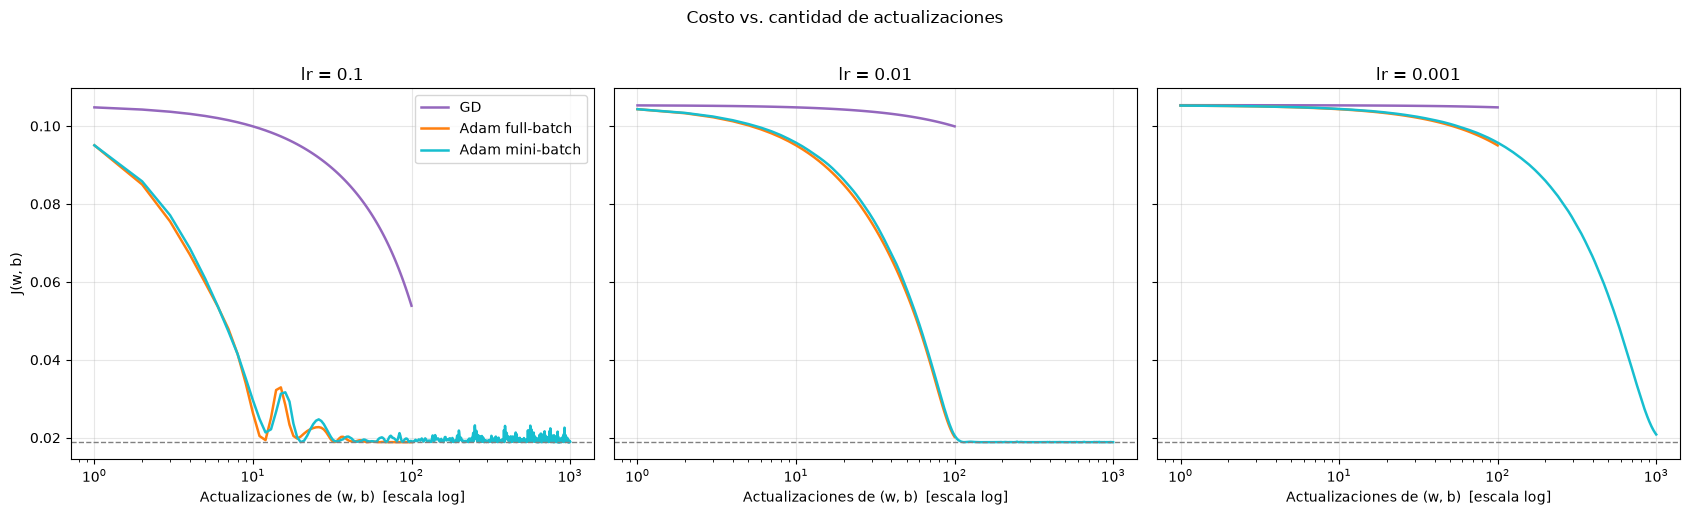

In [8]:
# Mismo costo pero en función de la cantidad de actualizaciones de parámetros (eje x logarítmico)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, lr in zip(axes, LRS):
    for nombre, hist in OPTIMIZADORES.items():
        J_upd = hist[lr]["J_upd"]     # J_upd[0] es el punto inicial (0 actualizaciones)
        ax.plot(np.arange(1, len(J_upd)), J_upd[1:], label=nombre, color=COLORES_OPT[nombre], linewidth=1.8)
    ax.axhline(J_opt, color="gray", ls="--", lw=1)
    ax.set_xscale("log"); ax.set_title(f"lr = {lr}"); ax.set_xlabel("Actualizaciones de (w, b)  [escala log]"); ax.grid(alpha=0.3)
axes[0].set_ylabel("J(w, b)"); axes[0].legend()
plt.suptitle("Costo vs. cantidad de actualizaciones", y=1.02)
plt.tight_layout(); plt.show()

**Lectura de las curvas y de la tabla.** Tomamos como referencia el mínimo de la grilla, $J^* = 0.0189$ en $(w^*, b^*) \approx (0.63, 0)$, y consideramos que un optimizador "convergió" cuando $J \leq 1.05\,J^*$.

- **`lr = 0.1`:** los dos Adam convergen, mini-batch en la época 2 y full-batch en la 12. GD es el único que baja sin ningún rebote en estas corridas (0 épocas con subida), pero termina en 0.054, casi 3 veces $J^*$. Adam full-batch tiene el rebote más grande (+0.007), típico de un momento que se pasa del mínimo. Mini-batch tiene rebotes más chicos pero que no se terminan (50 épocas con subida).
- **`lr = 0.01`:** solo mini-batch converge (época 11). Tiene 39 épocas con subidas, pero minúsculas (máximo +0.0001). Full-batch termina en 0,0202, apenas por encima del umbral de 0,0198, así que no llega a cruzarlo dentro de las 100 épocas, y GD apenas se movió.
- **`lr = 0.001`:** ninguno cruza el umbral. Mini-batch queda muy cerca (brecha 0.002), full-batch recorta apenas un 12% de la brecha de costo y GD prácticamente nada.

**Costo contra cantidad de actualizaciones.** El segundo gráfico separa dos efectos que en el eje de épocas aparecen mezclados:

1. Con los tres learning rates las curvas de Adam full-batch y mini-batch son casi idénticas. La ventaja de mini-batch "por época" **no viene de que sea un mejor algoritmo, sino de que actualiza 10 veces más por época**. Cada época usa las mismas 300 muestras para calcular gradientes en ambos casos, y mini-batch les saca más provecho porque actualiza 10 veces. Eso no significa que cueste lo mismo en tiempo: mini-batch hace muchas más iteraciones de Python, y en nuestra implementación además evalúa el costo completo en cada actualización para poder graficarlo.
2. En cambio, a igual cantidad de actualizaciones Adam le gana a GD: con `lr=0.1` y `lr=0.01` por mucho (a las 100 actualizaciones, 0.019 contra 0.054 y 0.020 contra 0.100), y con `lr=0.001` por poco (0.095 contra 0.105), porque ahí los dos avanzan muy poco. Esa diferencia sí es propia del algoritmo: la normalización por $\sqrt{\hat v_t}$ hace que el tamaño del paso no dependa de la escala del gradiente.

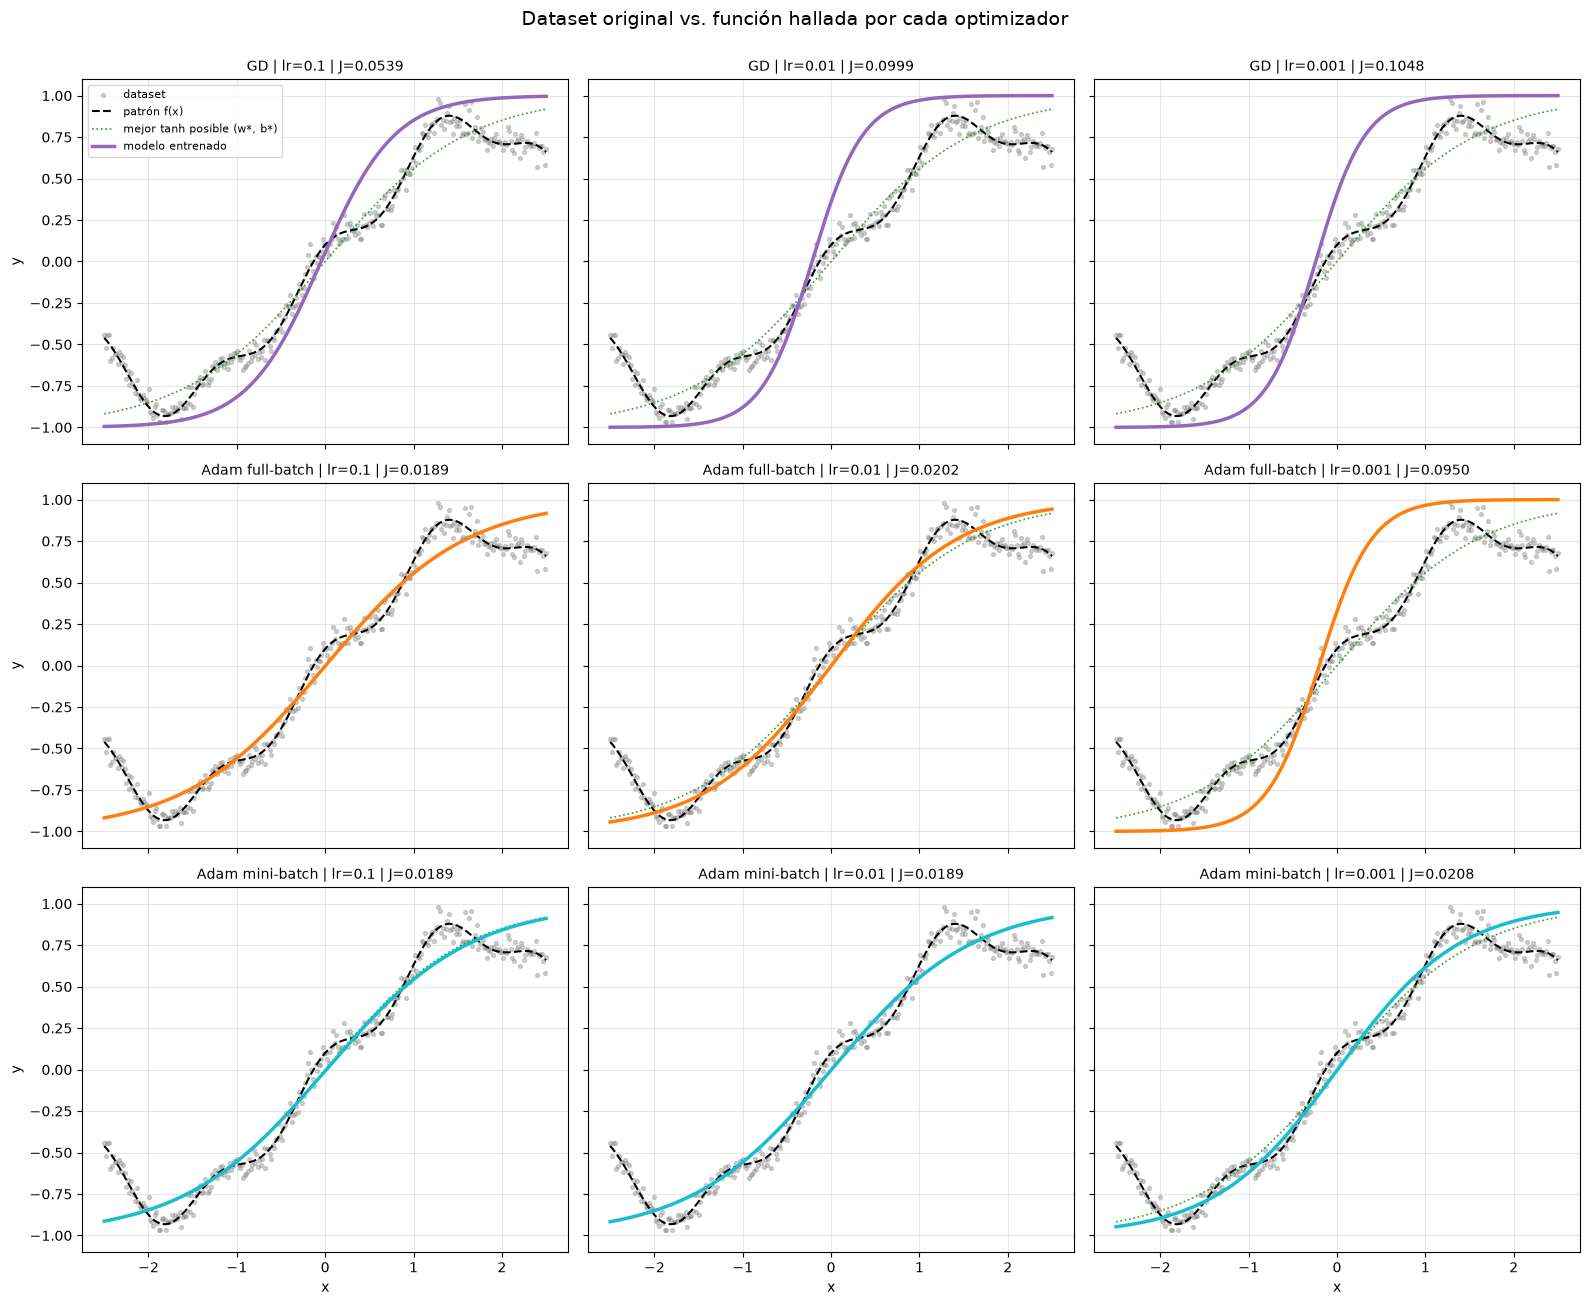

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13), sharex=True, sharey=True)
for i, (nombre, hist) in enumerate(OPTIMIZADORES.items()):
    for j, lr in enumerate(LRS):
        ax = axes[i, j]
        wf, bf = hist[lr]["w"][-1], hist[lr]["b"][-1]
        ax.scatter(x, y, s=8, alpha=0.35, color="gray", label="dataset")
        ax.plot(x, f_no_lineal(x), color="black", lw=1.5, ls="--", label="patrón f(x)")
        ax.plot(x, forward(w_opt, b_opt, x), color="tab:green", lw=1.2, ls=":", label="mejor tanh posible (w*, b*)")
        ax.plot(x, forward(wf, bf, x), color=COLORES_OPT[nombre], lw=2.5, label="modelo entrenado")
        ax.set_title(f"{nombre} | lr={lr} | J={hist[lr]['J'][-1]:.4f}", fontsize=10)
        ax.grid(alpha=0.3)
        if j == 0:
            ax.set_ylabel("y")
        if i == 2:
            ax.set_xlabel("x")
axes[0, 0].legend(fontsize=8, loc="upper left")
plt.suptitle("Dataset original vs. función hallada por cada optimizador", y=1.0, fontsize=14)
plt.tight_layout(); plt.show()

**¿El modelo logró deducir el patrón no lineal?** En parte, y lo que falta es una limitación de la arquitectura, no del optimizador.

Las corridas que convergieron (Adam full-batch `lr=0.1`, mini-batch `lr=0.1` y `lr=0.01`) terminan en la curva verde punteada, que es la mejor `tanh` que encontramos (el mínimo sobre la grilla fina de 1c, que usamos como referencia numérica). Esa curva sí es no lineal: reproduce la forma de "S" del patrón, con la zona central de pendiente fuerte y la curvatura hacia los extremos, y explica el 95% de la varianza de $y$. Lo que no puede capturar es todo lo que no es monótono:

- la ondulación de $0.1\cos(5x)$;
- la subida de $y$ para $x < -1.8$ (a la izquierda del mínimo local del patrón);
- la caída después de $x \approx 1.4$.

Una sola neurona $\tanh(wx+b)$ es siempre monótona en $x$, así que esa parte queda como error irreducible ($J^* \approx 0.019$, que incluye el ruido: $\sigma^2 = 0.0025$).

Las corridas que no convergieron (GD con los tres lr y Adam full-batch con `lr=0.001`) muestran otra cosa interesante: el modelo **también es no lineal, pero con la forma equivocada**. Como $w$ sigue cerca del valor inicial (entre 1.2 y 1.8), la transición es demasiado abrupta: en $x = 1.5$ la `tanh` ya vale entre 0.95 (con $w = 1.20$) y 0.996 (con $w = 1.79$), cuando el patrón real vale 0.87. Así sobreestima $|y|$ en los extremos. Adam full-batch con `lr=0.01` y mini-batch con `lr=0.001` quedan en un punto intermedio: casi la forma óptima, pero todavía con una pendiente un poco más empinada.

Las $w$ y $b$ finales de las corridas que convergieron son prácticamente iguales entre optimizadores (≈0.62–0.63 y ≈0), o sea que en este problema **los tres llegan a la misma solución cuando llegan**. La diferencia no está en la calidad final sino en si llegan o no dentro de las 100 épocas.

### Robustez frente a la inicialización

In [10]:
# ¿Las conclusiones dependen de la semilla elegida? Repetimos los 9 entrenamientos con 20 inicializaciones distintas
def entrenar_desde(w_ini, b_ini, lr, optimizador, epochs=EPOCHS):
    theta, m, v, t = np.array([w_ini, b_ini]), np.zeros(2), np.zeros(2), 0
    rng_mb = np.random.default_rng(0)
    for _ in range(epochs):
        if optimizador == "GD":
            theta = theta - lr * np.array(gradientes(theta[0], theta[1], x, y))
        elif optimizador == "Adam full-batch":
            t += 1
            theta, m, v = paso_adam(theta, np.array(gradientes(theta[0], theta[1], x, y)), m, v, t, lr)
        else:
            perm = rng_mb.permutation(N)
            for inicio in range(0, N, BATCH_SIZE):
                idx = perm[inicio:inicio + BATCH_SIZE]
                t += 1
                theta, m, v = paso_adam(theta, np.array(gradientes(theta[0], theta[1], x[idx], y[idx])), m, v, t, lr)
    return costo(theta[0], theta[1], x, y)

SEMILLAS = range(20)
inicios = {}
for s in SEMILLAS:
    np.random.seed(s)
    inicios[s] = (np.random.randn(), np.random.randn())

filas = []
for s, (wi, bi) in inicios.items():
    for lr in LRS:
        for nombre in OPTIMIZADORES:
            filas.append({"semilla": s, "lr": lr, "Optimizador": nombre, "J final": entrenar_desde(wi, bi, lr, nombre)})
robustez = pd.DataFrame(filas)
robustez["convergió"] = robustez["J final"] <= UMBRAL

resumen = robustez.pivot_table(index="lr", columns="Optimizador", values="convergió", aggfunc="sum").sort_index(ascending=False)
resumen = resumen[list(OPTIMIZADORES)].astype(int)
print(f"Cantidad de inicializaciones (de {len(SEMILLAS)}) en las que cada optimizador llega a J <= 1.05·J* en 100 épocas:")
display(resumen)

mediana = robustez.pivot_table(index="lr", columns="Optimizador", values="J final", aggfunc="median").sort_index(ascending=False)
print("Mediana del J final sobre las 20 inicializaciones:")
display(mediana[list(OPTIMIZADORES)].round(4))

orden_ok = sum(
    (g.set_index("Optimizador")["J final"]["Adam mini-batch"] <= g.set_index("Optimizador")["J final"]["Adam full-batch"] + 1e-3)
    and (g.set_index("Optimizador")["J final"]["Adam full-batch"] <= g.set_index("Optimizador")["J final"]["GD"] + 1e-3)
    for _, g in robustez.groupby(["semilla", "lr"])
)
print(f"Combinaciones (semilla, lr) donde se cumple J(mini-batch) <= J(full-batch) <= J(GD) (tolerancia 0.001): {orden_ok} de {len(SEMILLAS) * len(LRS)}")

dist = pd.Series({s: np.hypot(wi - w_opt, bi - b_opt) for s, (wi, bi) in inicios.items()})
print(f"Distancia del punto inicial al mínimo: semilla 3 = {dist[3]:.2f} | mediana de las 20 semillas = {dist.median():.2f} | rango = [{dist.min():.2f}, {dist.max():.2f}]")

Cantidad de inicializaciones (de 20) en las que cada optimizador llega a J <= 1.05·J* en 100 épocas:


Optimizador,GD,Adam full-batch,Adam mini-batch
lr,,,
0.100,11,18,20
0.010,0,6,20
0.001,0,0,6


Mediana del J final sobre las 20 inicializaciones:


Optimizador,GD,Adam full-batch,Adam mini-batch
lr,,,
0.100,0.0191,0.0189,0.0189
0.010,0.0946,0.0217,0.0189
0.001,0.2357,0.2333,0.0235


Combinaciones (semilla, lr) donde se cumple J(mini-batch) <= J(full-batch) <= J(GD) (tolerancia 0.001): 53 de 60
Distancia del punto inicial al mínimo: semilla 3 = 1.24 | mediana de las 20 semillas = 1.16 | rango = [0.38, 2.26]


Para verificar que las conclusiones no son un efecto de la semilla elegida, repetimos los 9 entrenamientos (3 optimizadores × 3 learning rates) desde 20 inicializaciones aleatorias distintas con `np.random.randn()`.

**El orden se mantiene.** Adam mini-batch converge con las 20 inicializaciones con `lr=0.1` y `lr=0.01`, y es el único que converge alguna vez con `lr=0.001` (6 de 20). Adam full-batch converge en 18 y 6 de 20 con `lr=0.1` y `lr=0.01`. GD solo converge con `lr=0.1` (11 de 20) y nunca con los learning rates más chicos. Las medianas del costo final muestran lo mismo. La semilla 3 no es un caso excepcional: su distancia al mínimo (1.24) es muy parecida a la mediana (1.16), y semillas como la 0, 1, 7 u 11 dan resultados casi iguales.

**Las excepciones confirman el mecanismo.** El orden mini-batch ≤ full-batch ≤ GD se cumple en 53 de las 60 combinaciones. En las 7 restantes, Adam mini-batch sigue siendo el mejor, pero Adam full-batch termina *peor* que GD. Todas esas inicializaciones arrancan con $w_0$ cercano a cero o negativo (entre −0.71 y 0.05), es decir, con una `tanh` plana o con la pendiente al revés. Ahí el costo inicial es alto (0.47 a 1.6) y el gradiente es grande ($|\partial J/\partial w|$ entre 1.1 y 1.9, o sea entre 29 y 49 veces el de la semilla 3, donde vale 0.039). Como el paso de GD es $\eta\,|\nabla J|$ y el de Adam es ≈ $\eta$ sin importar la escala del gradiente, cuando el gradiente es mayor que 1 **GD da pasos más largos que Adam** y avanza más rápido. Es el mismo argumento de 1a y 1b visto desde el otro lado: la ventaja de Adam no es universal, sino que aparece cuando los gradientes son chicos, como pasa en la mayoría de las inicializaciones que probamos.

### Conclusiones de la comparativa

1. **Calidad de la solución final.** Cuando convergen, GD, Adam full-batch y Adam mini-batch terminan en el mismo $(w, b)$ y el mismo costo. En esta superficie hay un solo valle en la zona recorrida, así que el optimizador no cambia *dónde* se termina sino *cuánto tarda* en llegar.

2. **Velocidad y sensibilidad al learning rate.** Es la diferencia más grande. El paso de GD es proporcional al gradiente, y acá el gradiente es chico ($|\nabla J| \approx 0.07$), así que GD no llega con ninguno de los tres lr. Para cubrir la distancia de ≈1.24 con `lr=0.1` necesitaría como mínimo ≈170 épocas, y eso suponiendo que avanzara siempre en línea recta hacia el mínimo. El paso de Adam, en cambio, no escala con la magnitud del gradiente: arranca en ≈lr por parámetro y después se ajusta según el historial (en estas corridas, con `lr=0.1` el paso medio terminó siendo 0.0256, porque se achica al acercarse al mínimo). Eso lo hace mucho más rápido acá y también cambia cómo conviene pensar el lr: con Adam fija el orden de magnitud del desplazamiento por paso, así que si la distancia a recorrer es grande (como con `lr=0.001` en full-batch), 100 pasos no alcanzan.

3. **Estabilidad.** GD es el único monótono (nunca sube el costo). Adam full-batch con lr grande se pasa del mínimo y oscila por el momento de primer orden, aunque las oscilaciones se amortiguan. Adam mini-batch con lr grande no se estabiliza nunca, por el ruido del gradiente estimado con 30 muestras. Para dejarlo quieto en el mínimo habría que bajar el lr a medida que se entrena (lr decreciente), o usar un lr más chico desde el principio, como se ve con `lr=0.01`, donde casi no hay rebotes.

4. **Eficiencia por época vs. por actualización.** Mini-batch aprovecha mejor cada época porque hace 10 actualizaciones recorriendo las mismas 300 muestras (en tiempo de cómputo no son equivalentes: mini-batch hace muchas más iteraciones). Actualización por actualización, en cambio, se comporta igual que full-batch. Comparar optimizadores solo en el eje de épocas mezcla estos dos efectos.

5. **Mejor combinación en este problema:** Adam mini-batch con `lr=0.01`. Converge en 11 épocas sin rebotes apreciables. Con `lr=0.1` converge antes pero queda oscilando, y con `lr=0.001` es demasiado lento.

### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

Elegimos **`lr = 0.1`** porque es el learning rate donde los tres optimizadores muestran comportamientos cualitativamente distintos:

- GD avanza pero queda a mitad de camino.
- Adam full-batch llega y se pasa del mínimo.
- Adam mini-batch llega rápido pero queda oscilando.

Con `lr=0.01` las trayectorias de los dos Adam son casi la misma curva y GD casi no se mueve. Con `lr=0.001` ninguno de los dos full-batch se aleja del punto inicial.

Además del gráfico 3D pedido, sumamos la vista de curvas de nivel porque en 3D la trayectoria de mini-batch alrededor del mínimo queda tapada por la superficie. Para mini-batch graficamos todas las actualizaciones (1000 puntos), no solo el final de cada época, porque así se ve el zigzag que producen los lotes.

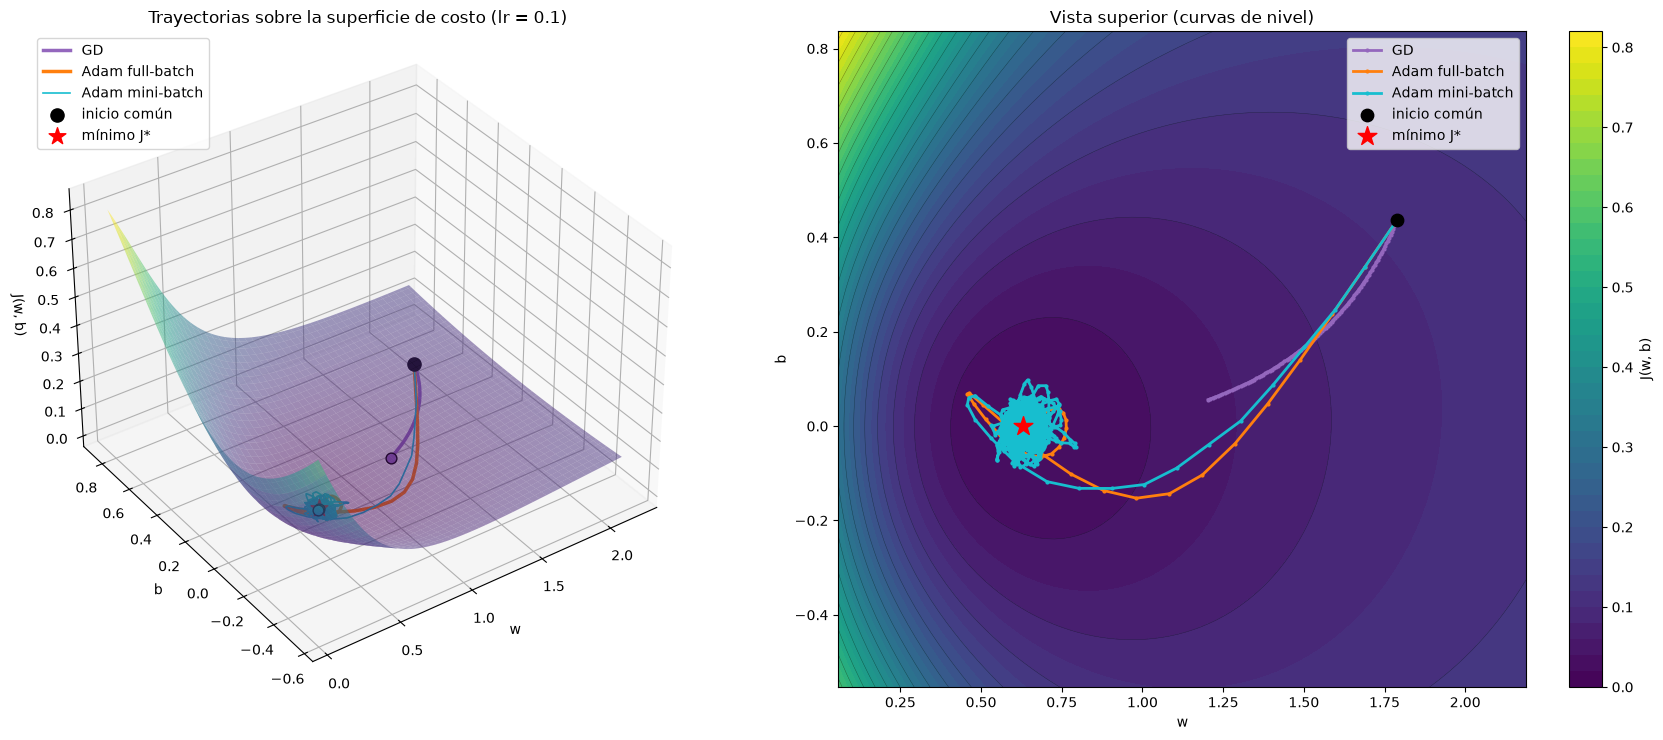

In [11]:
LR_3D = 0.1

trayectorias = {nombre: hist[LR_3D] for nombre, hist in OPTIMIZADORES.items()}

# Malla de la superficie alrededor de la zona que recorren las trayectorias
todos_w = np.concatenate([t["w_upd"] for t in trayectorias.values()] + [[w_opt]])
todos_b = np.concatenate([t["b_upd"] for t in trayectorias.values()] + [[b_opt]])
W, B = np.meshgrid(np.linspace(todos_w.min() - 0.4, todos_w.max() + 0.4, 90),
                   np.linspace(todos_b.min() - 0.4, todos_b.max() + 0.4, 90))
J_sup = np.array([[costo(W[i, j], B[i, j], x, y) for j in range(W.shape[1])] for i in range(W.shape[0])])

fig = plt.figure(figsize=(18, 7.5))
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax3d.plot_surface(W, B, J_sup, cmap="viridis", alpha=0.5, linewidth=0, antialiased=True)
for nombre, t in trayectorias.items():
    grosor = 1.2 if nombre == "Adam mini-batch" else 2.5
    ax3d.plot(t["w_upd"], t["b_upd"], t["J_upd"], color=COLORES_OPT[nombre], lw=grosor, label=nombre)
    ax3d.scatter(t["w_upd"][-1], t["b_upd"][-1], t["J_upd"][-1], color=COLORES_OPT[nombre], s=60, edgecolor="black", zorder=5)
ax3d.scatter(w0, b0, costo(w0, b0, x, y), color="black", s=90, marker="o", label="inicio común")
ax3d.scatter(w_opt, b_opt, J_opt, color="red", s=160, marker="*", label="mínimo J*")
ax3d.set_xlabel("w"); ax3d.set_ylabel("b"); ax3d.set_zlabel("J(w, b)")
ax3d.set_title(f"Trayectorias sobre la superficie de costo (lr = {LR_3D})")
ax3d.view_init(elev=35, azim=-125)
ax3d.legend(loc="upper left")

ax2d = fig.add_subplot(1, 2, 2)
cf = ax2d.contourf(W, B, J_sup, levels=40, cmap="viridis")
ax2d.contour(W, B, J_sup, levels=20, colors="k", linewidths=0.3, alpha=0.5)
fig.colorbar(cf, ax=ax2d, label="J(w, b)")
for nombre, t in trayectorias.items():
    ax2d.plot(t["w_upd"], t["b_upd"], color=COLORES_OPT[nombre], lw=2, label=nombre, marker="o", markersize=2)
ax2d.scatter(w0, b0, color="black", s=80, zorder=5, label="inicio común")
ax2d.scatter(w_opt, b_opt, color="red", s=200, marker="*", zorder=5, label="mínimo J*")
ax2d.set_xlabel("w"); ax2d.set_ylabel("b"); ax2d.set_title("Vista superior (curvas de nivel)")
ax2d.legend(loc="upper right")
plt.tight_layout(); plt.show()

In [12]:
# Cuantificación de cómo se mueve cada optimizador en el espacio de parámetros
filas = []
for nombre, t in trayectorias.items():
    pasos = np.sqrt(np.diff(t["w_upd"]) ** 2 + np.diff(t["b_upd"]) ** 2)
    filas.append({
        "Optimizador": nombre,
        "Actualizaciones": len(pasos),
        "Tamaño de paso medio": pasos.mean(),
        "Tamaño de paso máx.": pasos.max(),
        "Distancia recorrida total": pasos.sum(),
        "Distancia final al mínimo": np.hypot(t["w_upd"][-1] - w_opt, t["b_upd"][-1] - b_opt),
        "J final": t["J_upd"][-1],
    })
display(pd.DataFrame(filas).round(4))

# Norma del gradiente a lo largo de la trayectoria de GD: muestra cuán plana es la zona que atraviesa
t_gd = trayectorias["GD"]
normas = np.array([np.hypot(*gradientes(wi, bi, x, y)) for wi, bi in zip(t_gd["w_upd"], t_gd["b_upd"])])
print(f"|∇J| en el punto inicial = {normas[0]:.4f}")
print(f"|∇J| mínimo sobre la trayectoria de GD = {normas.min():.4f}  |  máximo = {normas.max():.4f}")
print(f"Distancia en línea recta entre el inicio y el mínimo = {np.hypot(w0 - w_opt, b0 - b_opt):.3f}")

# Chequeo de no convexidad: autovalores del Hessiano (diferencias finitas) en una grilla amplia de (w, b)
def hessiano(w, b, h=1e-3):
    Jww = (costo(w + h, b, x, y) - 2 * costo(w, b, x, y) + costo(w - h, b, x, y)) / h**2
    Jbb = (costo(w, b + h, x, y) - 2 * costo(w, b, x, y) + costo(w, b - h, x, y)) / h**2
    Jwb = (costo(w + h, b + h, x, y) - costo(w + h, b - h, x, y) - costo(w - h, b + h, x, y) + costo(w - h, b - h, x, y)) / (4 * h**2)
    return np.array([[Jww, Jwb], [Jwb, Jbb]])

puntos = [(wi, bi) for wi in np.linspace(-4, 4, 41) for bi in np.linspace(-2, 2, 21)]
no_convexos = sum(np.linalg.eigvalsh(hessiano(wi, bi)).min() < 0 for wi, bi in puntos)
print(f"Puntos de la grilla w∈[-4,4], b∈[-2,2] con Hessiano NO semidefinido positivo: {no_convexos} de {len(puntos)} ({no_convexos / len(puntos):.0%})")

,Optimizador,Actualizaciones,Tamaño de paso medio,Tamaño de paso máx.,Distancia recorrida total,Distancia final al mínimo,J final
0,GD,100,0.0072,0.0076,0.7172,0.5761,0.0539
1,Adam full-batch,100,0.0256,0.1414,2.5569,0.0031,0.0189
2,Adam mini-batch,1000,0.0206,0.1414,20.5718,0.0159,0.0189


|∇J| en el punto inicial = 0.0753
|∇J| mínimo sobre la trayectoria de GD = 0.0693  |  máximo = 0.0758
Distancia en línea recta entre el inicio y el mínimo = 1.238
Puntos de la grilla w∈[-4,4], b∈[-2,2] con Hessiano NO semidefinido positivo: 826 de 861 (96%)


**La superficie.** $J(w,b)$ no es convexa en la región que inspeccionamos: sobre una grilla de $w \in [-4, 4]$ y $b \in [-2, 2]$, el 96% de los puntos tiene algún autovalor negativo del Hessiano (calculado por diferencias finitas). Es coherente con la saturación de la `tanh`: para $|w|$ o $|b|$ grandes, $J$ se aplana y deja de curvarse hacia arriba, como se ve a la derecha del gráfico 3D. Alrededor del mínimo, en cambio, la curvatura es positiva. Las tres trayectorias arrancan en $(1.79, 0.44)$, en la pendiente suave del valle, donde la norma del gradiente es ≈0.075 y cambia muy poco a lo largo del camino (0.069–0.076).

**GD (violeta).** Sigue exactamente la dirección de $-\nabla J$, perpendicular a las curvas de nivel, con una trayectoria suave y sin oscilaciones. Todos sus pasos miden casi lo mismo (≈0.0072 = lr × |∇J|) porque el gradiente casi no cambia. Recorre 0.72 unidades en total y queda en $(1.20, 0.06)$, a 0.58 del mínimo. En el 3D se ve cómo baja por la ladera pero se queda antes del fondo del valle.

**Adam full-batch (naranja).** Su primer paso mide 0.141 = lr·√2, casi 20 veces el paso de GD. Esto confirma que Adam da pasos de ≈lr en *cada* parámetro por separado. Como normaliza cada coordenada por su propio historial, **la dirección del paso no es la del gradiente**. En el punto inicial el gradiente es $(\partial J/\partial w, \partial J/\partial b) \approx (0.039, 0.064)$, y GD se mueve en esa proporción (al principio baja más en $b$ que en $w$). Adam, en cambio, mueve los dos parámetros ≈lr por paso, así que en proporción avanza más en $w$ de lo que indicaría el gradiente. Como $b$ tiene que recorrer menos distancia (0.44 contra 1.16 en $w$), llega a cero primero, y el momento acumulado lo hace pasarse hasta $b \approx -0.15$ mientras $w$ sigue bajando. Por eso la trayectoria naranja se va por debajo de la violeta y después se curva hacia el mínimo. Al llegar, el momento la hace pasar de largo también en $w$, hasta $w \approx 0.46$, y vuelve con oscilaciones cada vez más chicas. Recorre 2.56 unidades, el doble de la distancia en línea recta, y termina a 0.003 del mínimo.

**Adam mini-batch (cian).** Durante las primeras actualizaciones sigue casi el mismo camino que full-batch: con lotes de 30 muestras el gradiente estimado apunta a una dirección parecida al gradiente completo. Llega al mínimo en unas pocas épocas porque hace 10 pasos por época. Pero una vez ahí, el ruido de cada lote lo hace saltar alrededor del mínimo y forma la "nube" que se ve en las curvas de nivel. Recorre en total 20.6 unidades, casi todo en ese zigzag, y termina a 0.016 del mínimo. El costo final es el mismo que el de full-batch porque cerca del mínimo la superficie es casi plana y moverse un poco no cambia $J$.

**En resumen:** GD se mueve de forma ordenada pero lenta, porque su paso escala con un gradiente que acá es chico. Adam full-batch se mueve rápido y en una dirección distinta a la del gradiente, a costa de pasarse y oscilar. Adam mini-batch combina la velocidad de Adam con muchas más actualizaciones por época, pero con lr grande no logra quedarse quieto en el mínimo.

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


> **Nota sobre el alcance de esta pregunta.** El profesor aclaró por correo que la mención a clientes con 3 a 5 compras describe un escenario hipotético de uso futuro del modelo, y **no** una instrucción de recortar el dataset a las primeras compras de cada cliente (que además sería imposible, porque no hay ninguna variable temporal). Lo que sí pide evitar es que el modelo dependa de la cantidad acumulada de compras de cada usuario. Por eso usamos **todas** las transacciones disponibles de cada cliente y construimos features de perfil que no crecen con el volumen; lo verificamos con datos en la sección "¿Qué features dependen de cuántas compras acumuló el cliente?".

### Carga y primera mirada al dataset

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

ARCHIVO = "dataset.csv"
if not os.path.exists(ARCHIVO):
    import gdown
    gdown.download("https://drive.google.com/uc?id=1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ", ARCHIVO, quiet=False)

df = pd.read_csv(ARCHIVO)
print("Shape:", df.shape)
df.head()

Shape: (182721, 11)


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [14]:
df.info()
print("\nNulos por columna (cantidad y %):")
print(pd.DataFrame({"nulos": df.isnull().sum(), "%": (df.isnull().mean() * 100).round(1)}))
print("\nValores únicos por columna:")
print(df.nunique())
print("\nPurchase (monto por transacción):")
print(df["Purchase"].describe().round(1))
print("Asimetría (skew):", round(df["Purchase"].skew(), 3))

<class 'pandas.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  str    
 2   Age                         182721 non-null  str    
 3   Gender                      182721 non-null  str    
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  str    
 6   Stay_In_Current_City_Years  182721 non-null  str    
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 15.3 MB

Nulos por columna (cantidad y %):
                             nulos     %
User_ID    

El dataset tiene 182.721 transacciones de 7.432 clientes sobre 2.455 productos. Solo dos columnas tienen nulos: `Product_Subcategory_1` (22,9%) y `Product_Subcategory_2` (57,6%); más abajo analizamos qué significan. `Purchase` va de \$45 a \$29.980, con media \$7.852 y mediana \$5.060: la distribución tiene asimetría positiva (skew ≈ 1,1), con muchas compras baratas y una cola de compras caras. Un detalle llamativo es que `Purchase` tiene solo 1.833 valores distintos en 182 mil transacciones, lo que ya sugiere que el monto no es algo "libre" de cada transacción sino que depende del producto.

### EDA a nivel transacción

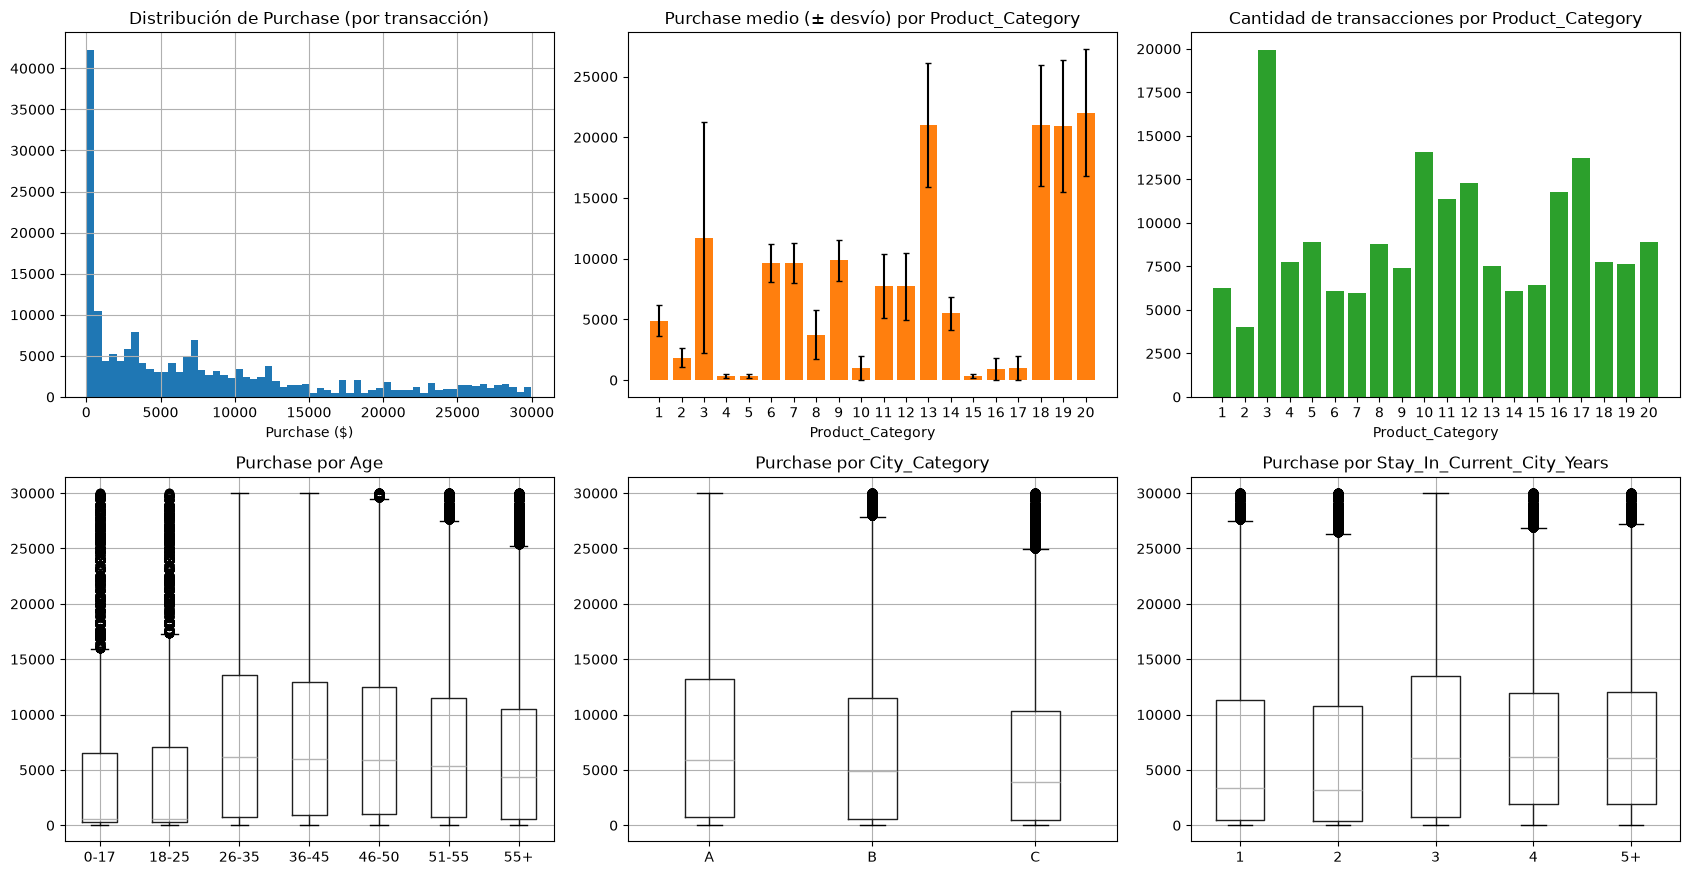

Purchase por Product_Category:
Product_Category      1       2        3       4       5       6       7       8       9        10       11       12       13      14      15       16       17       18       19       20
mean              4897.0  1835.0  11748.0   338.0   325.0  9665.0  9670.0  3758.0  9856.0    995.0   7743.0   7729.0  20985.0  5491.0   326.0    916.0    990.0  20975.0  20931.0  22033.0
std               1255.0   781.0   9506.0   169.0   166.0  1557.0  1645.0  2024.0  1691.0   1011.0   2621.0   2779.0   5119.0  1359.0   158.0    934.0   1010.0   4957.0   5417.0   5248.0
count             6261.0  4032.0  19950.0  7764.0  8889.0  6070.0  5979.0  8796.0  7408.0  14068.0  11388.0  12294.0   7549.0  6073.0  6406.0  11783.0  13711.0   7772.0   7621.0   8907.0


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

df["Purchase"].hist(bins=60, ax=axes[0, 0], color="tab:blue")
axes[0, 0].set_title("Distribución de Purchase (por transacción)"); axes[0, 0].set_xlabel("Purchase ($)")

stats_cat = df.groupby("Product_Category")["Purchase"].agg(["mean", "std", "count"])
axes[0, 1].bar(stats_cat.index.astype(str), stats_cat["mean"], yerr=stats_cat["std"], color="tab:orange", capsize=2)
axes[0, 1].set_title("Purchase medio (± desvío) por Product_Category"); axes[0, 1].set_xlabel("Product_Category")

axes[0, 2].bar(stats_cat.index.astype(str), stats_cat["count"], color="tab:green")
axes[0, 2].set_title("Cantidad de transacciones por Product_Category"); axes[0, 2].set_xlabel("Product_Category")

for ax, col in zip(axes[1], ["Age", "City_Category", "Stay_In_Current_City_Years"]):
    df.boxplot(column="Purchase", by=col, ax=ax)
    ax.set_title(f"Purchase por {col}"); ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout(); plt.show()

print("Purchase por Product_Category:")
print(stats_cat.round(0).T)

In [16]:
# ¿Qué parte de la variación del monto por transacción se explica por el producto comprado?
from sklearn.metrics import r2_score

def r2_por_grupo(columnas):
    pred = df.groupby(columnas)["Purchase"].transform("mean")
    return r2_score(df["Purchase"], pred)

df_sub = df.fillna({"Product_Subcategory_1": 0, "Product_Subcategory_2": 0})
print(f"R² de Purchase explicado por el promedio de su Product_Category:              {r2_por_grupo('Product_Category'):.3f}")
print(f"R² explicado por Product_Category + subcategorías (nulo = 0):                   "
      f"{r2_score(df['Purchase'], df_sub.groupby(['Product_Category', 'Product_Subcategory_1', 'Product_Subcategory_2'])['Purchase'].transform('mean')):.3f}")
print(f"R² explicado por el promedio de su Product_ID:                                  {r2_por_grupo('Product_ID'):.3f}")
print(f"R² explicado por el promedio de su grupo de Age:                                {r2_por_grupo('Age'):.3f}")
print(f"R² explicado por el promedio de su City_Category:                               {r2_por_grupo('City_Category'):.3f}")

R² de Purchase explicado por el promedio de su Product_Category:              0.764
R² explicado por Product_Category + subcategorías (nulo = 0):                   0.919
R² explicado por el promedio de su Product_ID:                                  1.000
R² explicado por el promedio de su grupo de Age:                                0.020
R² explicado por el promedio de su City_Category:                               0.006


Esta parte del EDA terminó definiendo todo el feature engineering:

- **El monto de una transacción lo determina el producto, no el cliente.** El promedio por `Product_ID` explica prácticamente el 100% de la varianza de `Purchase`: cada producto se vende siempre al mismo precio. Solo con `Product_Category` ya se explica el 76%, y con las subcategorías el 92%.
- **Las categorías tienen niveles de precio muy distintos.** Las 4, 5 y 15 rondan los \$330; las 10, 16 y 17, menos de \$1.000; las 13, 18, 19 y 20, entre \$20.900 y \$22.000. Además las baratas son muy frecuentes (la 4, 5, 10, 16 y 17 juntas suman 56.215 transacciones), lo que explica el pico cerca de cero del histograma. La categoría 3 es la única con precios muy dispersos (desvío \$9.500).
- **Las variables demográficas casi no explican el monto de una transacción** (Age: 2%; City_Category: 0,6%). En los boxplots se ven diferencias de mediana (los grupos 0-17 y 18-25 compran más barato; la ciudad A, un poco más caro), pero los rangos se superponen casi por completo.

Conclusión para el objetivo: si el precio lo fija el producto, el gasto promedio de un cliente depende sobre todo de **qué tipo de productos compra**. Las features de comportamiento tienen que describir el mix de categorías de cada cliente, y los datos demográficos van a aportar poco por sí solos.

### Del nivel transacción al nivel cliente

Clientes con más de un valor distinto en cada columna demográfica:
  Age                         : 0 de 7432
  Gender                      : 0 de 7432
  Marital_Status              : 0 de 7432
  City_Category               : 0 de 7432
  Stay_In_Current_City_Years  : 0 de 7432

Transacciones por cliente:
count    7432.0
mean       24.6
std        13.7
min        10.0
25%        14.0
50%        18.0
75%        40.0
max        50.0
dtype: float64

Target = gasto promedio por cliente:
count     7432.0
mean      6749.7
std       3297.9
min        275.3
25%       4247.4
50%       6330.2
75%       8519.2
max      17231.1
Name: avg_purchase, dtype: float64
Asimetría del target: 0.539


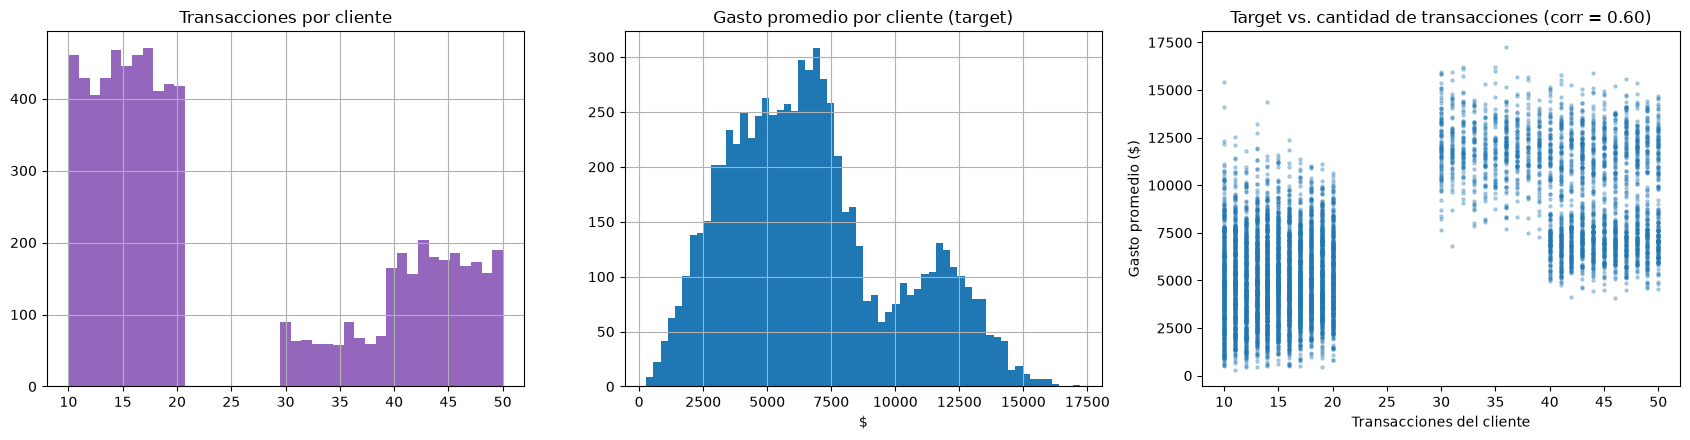

In [17]:
demo_cols = ["Age", "Gender", "Marital_Status", "City_Category", "Stay_In_Current_City_Years"]
print("Clientes con más de un valor distinto en cada columna demográfica:")
for col in demo_cols:
    print(f"  {col:28s}: {(df.groupby('User_ID')[col].nunique() > 1).sum()} de {df['User_ID'].nunique()}")

txn_por_cliente = df.groupby("User_ID").size()
target = df.groupby("User_ID")["Purchase"].mean().rename("avg_purchase")
print("\nTransacciones por cliente:"); print(txn_por_cliente.describe().round(1))
print("\nTarget = gasto promedio por cliente:"); print(target.describe().round(1))
print("Asimetría del target:", round(target.skew(), 3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
txn_por_cliente.hist(bins=41, ax=axes[0], color="tab:purple"); axes[0].set_title("Transacciones por cliente")
target.hist(bins=60, ax=axes[1], color="tab:blue"); axes[1].set_title("Gasto promedio por cliente (target)"); axes[1].set_xlabel("$")
axes[2].scatter(txn_por_cliente, target, s=5, alpha=0.3)
axes[2].set_xlabel("Transacciones del cliente"); axes[2].set_ylabel("Gasto promedio ($)")
axes[2].set_title(f"Target vs. cantidad de transacciones (corr = {np.corrcoef(txn_por_cliente, target)[0, 1]:.2f})")
plt.tight_layout(); plt.show()

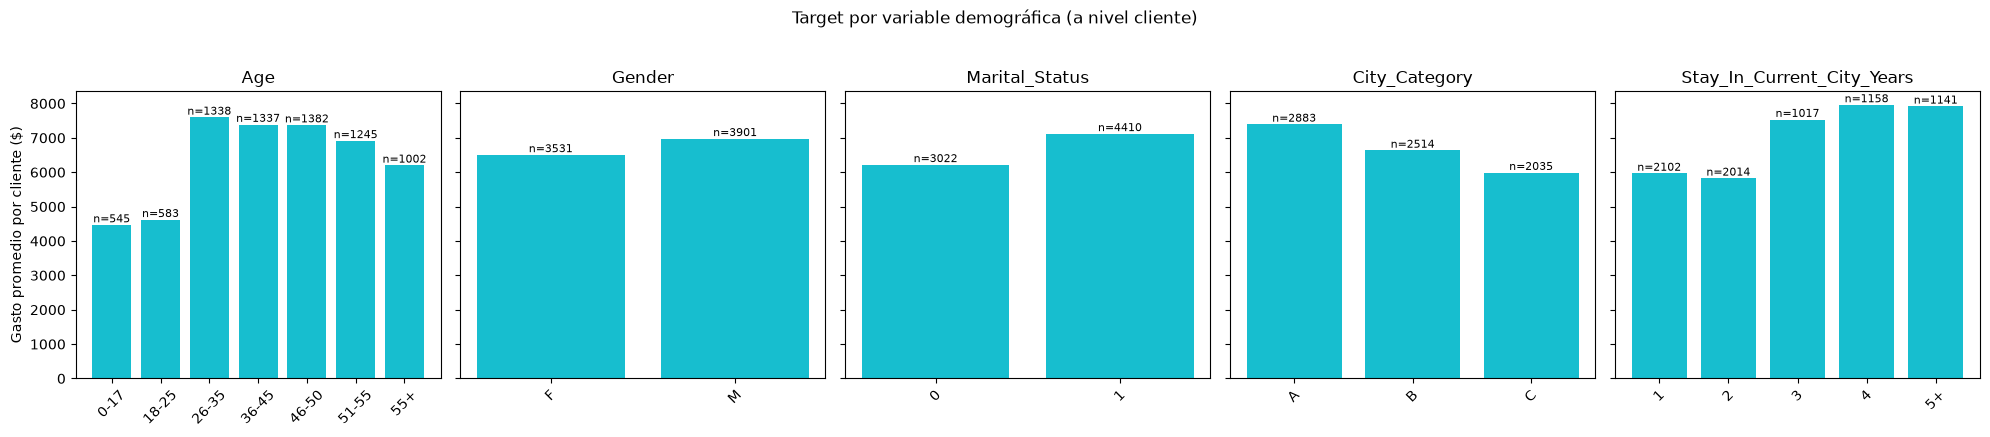

In [18]:
clientes = df.groupby("User_ID")[demo_cols].first().join(target)

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2), sharey=True)
for ax, col in zip(axes, demo_cols):
    g = clientes.groupby(col)["avg_purchase"].agg(["mean", "count"])
    g.index = g.index.astype(str)
    ax.bar(g.index, g["mean"], color="tab:cyan")
    for i, (m, c) in enumerate(zip(g["mean"], g["count"])):
        ax.text(i, m + 80, f"n={c}", ha="center", fontsize=8)
    ax.set_title(col); ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Gasto promedio por cliente ($)")
plt.suptitle("Target por variable demográfica (a nivel cliente)", y=1.03)
plt.tight_layout(); plt.show()

**Las columnas demográficas son atributos del cliente.** Ningún cliente tiene más de un valor en `Age`, `Gender`, `Marital_Status`, `City_Category` o `Stay_In_Current_City_Years`, así que se pueden llevar directo a una fila por cliente.

**El target** (gasto promedio por cliente) va de \$275 a \$17.231, con media \$6.750 y desvío \$3.298. Es bimodal: un grupo grande alrededor de \$5.000–7.000 y otro alrededor de \$12.000. La asimetría es moderada (0,54), así que no vemos necesario transformarlo con logaritmo; sí lo estandarizamos para entrenar la red.

**Transacciones por cliente.** Van de 10 a 50, con una estructura que probablemente venga de cómo se generó el dataset: no hay ningún cliente con 21 a 29 transacciones. Los 678 clientes con 30–39 transacciones gastan en promedio \$11.919 (ninguno baja de \$6.824), los de 10–20 gastan \$5.108 y los de 40–50, \$9.015. Por eso la cantidad de transacciones tiene correlación 0,60 con el target.

Esa correlación es tentadora, pero es justamente el motivo por el que **no vamos a usar la cantidad de transacciones como feature**: el modelo tiene que servir para clientes con pocas compras, y si aprende que "el que compró muchas veces gasta más", con un cliente nuevo de 5 compras va a predecir mal. Lo analizamos en detalle en la próxima sección.

**Demografía vs. target:**

- **Age:** los grupos 0-17 y 18-25 gastan ≈\$4.500 y los de 26 a 50, entre \$7.370 y \$7.594; después baja (51-55: \$6.910; 55+: \$6.200). Hay orden, pero la relación no es monótona.
- **City_Category:** el gasto baja de A (\$7.390) a B (\$6.630) y a C (\$5.990), en línea con el nivel socioeconómico descripto.
- **Stay_In_Current_City_Years:** hay un escalón entre 1–2 años (≈\$5.900) y 3 o más (\$7.530 a \$7.960).
- **Gender:** \$6.503 (F) contra \$6.973 (M). **Marital_Status:** \$6.215 contra \$7.116, una diferencia de \$900.

Son diferencias reales pero chicas frente al desvío del target (\$3.298): una regresión lineal solo con demografía llega a R² ≈ 0,28.

Una aclaración sobre `Stay_In_Current_City_Years`: la consigna la define como los años que el cliente lleva comprando en la tienda, o sea antigüedad. Medimos su correlación con la cantidad de transacciones y da 0,43, más alta que la de cualquiera de las 20 proporciones (la mayor es 0,389). En ese sentido es un proxy parcial del volumen, así que la miramos con la misma desconfianza que a los contadores. La dejamos porque es un dato que la tienda conoce en el momento de predecir, y porque empíricamente casi no influye: sacarla no mueve el R² de la regresión lineal (0,9403 con y sin ella).

### Valores nulos: `Product_Subcategory_1` y `Product_Subcategory_2`

In [19]:
for col in ["Product_Subcategory_1", "Product_Subcategory_2"]:
    es_nulo = df[col].isna()
    mixtos = df.assign(nulo=es_nulo).groupby("Product_ID")["nulo"].nunique().gt(1).sum()
    print(f"{col}: {es_nulo.mean():.1%} nulos | productos que a veces tienen nulo y a veces no: {mixtos} de {df['Product_ID'].nunique()}")
    print(df.assign(es_nulo=es_nulo).groupby("es_nulo")["Purchase"].agg(["count", "mean", "std"]).round(0), "\n")

print("Categorías con subcategoría 1 nula (% de sus transacciones):")
print((df.groupby("Product_Category")["Product_Subcategory_1"].apply(lambda s: s.isna().mean()) * 100).round(0).astype(int).to_dict())

Product_Subcategory_1: 22.9% nulos | productos que a veces tienen nulo y a veces no: 0 de 2455
          count    mean     std
es_nulo                        
False    140903  7786.0  8151.0
True      41818  8073.0  8868.0 

Product_Subcategory_2: 57.6% nulos | productos que a veces tienen nulo y a veces no: 0 de 2455
          count    mean     std
es_nulo                        
False     77461  7477.0  8104.0
True     105260  8127.0  8467.0 

Categorías con subcategoría 1 nula (% de sus transacciones):
{1: 20, 2: 22, 3: 21, 4: 21, 5: 25, 6: 21, 7: 19, 8: 23, 9: 20, 10: 24, 11: 19, 12: 21, 13: 30, 14: 21, 15: 20, 16: 28, 17: 25, 18: 26, 19: 32, 20: 16}


**La ausencia de subcategoría es consistente por producto.** Ningún producto la tiene a veces informada y a veces nula, así que el nulo es un atributo del producto y no un dato que se perdió en algunas transacciones. Con esta información no podemos distinguir entre "este producto no tiene subcategoría" y "no quedó registrada en el catálogo", pero en cualquiera de los dos casos imputar con la media o la moda no tiene sentido (sería inventar una subcategoría). Si se usan, lo correcto es tratar el nulo como una categoría más (`0 = sin subcategoría`).

Los nulos aparecen en todas las categorías (entre 16% y 32% en la subcategoría 1), y el monto medio de las transacciones con nulo es apenas distinto (sub. 1: \$8.073 vs \$7.786; sub. 2: \$8.127 vs \$7.477). La pregunta real es si **aportan información a nivel cliente** que no esté ya en `Product_Category`. A nivel transacción sí ayudan (el R² sube de 0,76 a 0,92), pero cuando se agregan por cliente las proporciones de subcategorías (con nulo = 0), el R² de validación de la regresión lineal pasa de 0,940 a 0,944 a cambio de 51 columnas nuevas y muy ralas (ver la tabla comparativa más abajo).

**Decisión: dropeamos ambas columnas.** No porque "no tengan salvación" (el nulo tiene significado y se podría usar), sino porque la mejora es de 0,003 en R² y casi triplica la cantidad de features (de 26 a 77) con solo 5.202 clientes de entrenamiento, lo que aumenta el riesgo de sobreajuste.

### Encodings: criterio por variable

| Variable | Tipo | Tratamiento | Por qué |
|---|---|---|---|
| `User_ID` | identificador | Solo para agrupar (no es feature) | Es una etiqueta sin significado numérico. Tampoco sirve un embedding (clase 4): un embedding aprende un vector por ID visto en entrenamiento, y los clientes a los que se quiere aplicar el modelo no están en train. |
| `Product_ID` | nominal, 2.455 valores | No se usa | One-hot daría 2.455 columnas por transacción. Label encoding inventaría un orden inexistente. Un embedding sería la alternativa de la clase 4, y de hecho la probamos en la sección extra del final: promediando los embeddings de los productos de cada cliente se puede usar a nivel cliente, y funciona muy bien con el historial completo, pero rinde peor que las proporciones cuando se conocen pocas compras. Por eso no entra en el modelo principal. Su encoding más directo, el precio medio del producto, es leakage (lo mostramos abajo). |
| `Age` | ordinal (rangos) | **Ordinal encoding** 0–6 | Los rangos tienen un orden natural y ordinal lo conserva en una sola columna. La relación con el target no es monótona (sube hasta 26–50 y después baja), pero eso lo puede aprender la red, que no es lineal. |
| `Gender` | binaria | **Mapping** F=0, M=1 | Dos valores: una columna 0/1 alcanza. |
| `Marital_Status` | binaria | Se deja como viene (0/1) | Ya está codificada. |
| `City_Category` | nominal (A/B/C) | **One-hot** con `drop_first=True` | A, B y C son tipos de zona, no cantidades. El gasto sí sigue el orden A > B > C, así que un ordinal también sería defendible, pero no sabemos si la "distancia" entre A y B es igual a la de B y C. One-hot deja que la red aprenda el efecto de cada zona y solo cuesta una columna más. `drop_first` evita la columna redundante. |
| `Stay_In_Current_City_Years` | ordinal | **Ordinal encoding** con un mapping a entero (`"5+"` → 5) | Es una cantidad de años con orden claro. `"5+"` agrupa 5 o más, así que lo tomamos como 5. |
| `Product_Category` | nominal, 20 valores | **Proporción de transacciones del cliente en cada categoría** (20 columnas) | Los números 1–20 son etiquetas (la categoría 20 no es "más" que la 1), así que no se pueden usar como número. Por transacción sería un one-hot de 20 columnas; al agregar por cliente, el promedio de ese one-hot es la proporción de compras en cada categoría. Describe el mix de productos, que es lo que determina el gasto, y **no crece con la cantidad de compras del cliente**. |
| `Product_Subcategory_1/2` | nominal con nulos estructurales | Dropeadas | Ver el análisis de nulos. |
| `Purchase` | numérica | **Solo para construir el target** | Cualquier feature derivada de `Purchase` filtra el target (ver la sección de leakage). |

Usamos todas las compras disponibles de cada cliente para construir las proporciones. Lo que evitamos no es usar el historial completo, sino resumirlo en variables que dependan de **cuántas** compras hizo.

### Construcción del dataset por cliente

In [20]:
AGE_ORDEN = ["0-17", "18-25", "26-35", "36-45", "46-50", "51-55", "55+"]

def encodear_demografia(datos):
    out = pd.DataFrame(index=datos.index)
    out["Age_ord"] = datos["Age"].map({a: i for i, a in enumerate(AGE_ORDEN)})                  # ordinal
    out["Gender_bin"] = datos["Gender"].map({"F": 0, "M": 1})                                   # mapping binario
    out["Marital_Status"] = datos["Marital_Status"]                                            # ya viene 0/1
    out["Stay_ord"] = datos["Stay_In_Current_City_Years"].astype(str).str.replace("+", "", regex=False).astype(int)  # ordinal
    city = pd.get_dummies(datos["City_Category"], prefix="City", drop_first=True).astype(int)   # one-hot
    return out.join(city)

def features_comportamiento(transacciones):
    # Proporción de TRANSACCIONES (no de gasto) en cada categoría.
    # No usa Purchase y su valor esperado no depende de cuántas compras tenga el cliente.
    conteos = pd.crosstab(transacciones["User_ID"], transacciones["Product_Category"])
    return conteos.div(conteos.sum(axis=1), axis=0).add_prefix("prop_cat_")

def features_volumen(transacciones):
    # Estas NO se usan como features (dependen de cuántas compras acumuló el cliente);
    # se construyen solo para mostrar por qué las descartamos.
    g = transacciones.groupby("User_ID")
    return pd.DataFrame({
        "n_transactions": g.size(),
        "n_unique_products": g["Product_ID"].nunique(),
        "n_unique_categories": g["Product_Category"].nunique(),
    })

def features_perfil(proporciones):
    # Resúmenes del perfil de compra que también evaluamos (y terminamos descartando).
    p = proporciones.values
    q = np.where(p > 0, p, 1.0)                      # p·log(p) -> 0 cuando p = 0
    return pd.DataFrame({
        "prop_categoria_favorita": p.max(axis=1),                          # concentración
        "diversidad_categorias": -(q * np.log(q)).sum(axis=1) / np.log(p.shape[1]),   # entropía normalizada
    }, index=proporciones.index)

demografia = encodear_demografia(df.groupby("User_ID")[demo_cols].first())
comportamiento = features_comportamiento(df)
volumen = features_volumen(df)              # solo para la comparación, no entran al modelo
perfil = features_perfil(comportamiento)    # idem
datos_clientes = demografia.join(comportamiento).join(target)

feature_cols = [c for c in datos_clientes.columns if c != "avg_purchase"]
print("Clientes:", len(datos_clientes), "| Features:", len(feature_cols))
print("Nulos en el dataset final:", datos_clientes.isnull().sum().sum())
datos_clientes.head()

Clientes: 7432 | Features: 26
Nulos en el dataset final: 0


,Age_ord,Gender_bin,Marital_Status,Stay_ord,City_B,City_C,prop_cat_1,prop_cat_2,prop_cat_3,prop_cat_4,prop_cat_5,prop_cat_6,prop_cat_7,prop_cat_8,prop_cat_9,prop_cat_10,prop_cat_11,prop_cat_12,prop_cat_13,prop_cat_14,prop_cat_15,prop_cat_16,prop_cat_17,prop_cat_18,prop_cat_19,prop_cat_20,avg_purchase
User_ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
1000035,1,1,0,1,0,0,0.000000,0.00000,0.000000,0.000000,0.153846,0.000000,0.076923,0.000000,0.076923,0.230769,0.000000,0.000000,0.000000,0.000000,0.076923,0.384615,0.000000,0.000000,0.000000,0.000000,1912.923077
1000044,3,1,1,4,0,0,0.023256,0.00000,0.116279,0.023256,0.000000,0.000000,0.116279,0.069767,0.069767,0.000000,0.023256,0.023256,0.093023,0.000000,0.023256,0.046512,0.046512,0.139535,0.069767,0.116279,14338.906977
1000070,4,1,1,4,1,0,0.047619,0.02381,0.023810,0.023810,0.023810,0.023810,0.119048,0.047619,0.071429,0.047619,0.071429,0.047619,0.000000,0.095238,0.071429,0.142857,0.119048,0.000000,0.000000,0.000000,4120.809524
1000087,6,0,1,4,0,1,0.048780,0.02439,0.024390,0.048780,0.024390,0.000000,0.048780,0.073171,0.048780,0.121951,0.024390,0.024390,0.073171,0.024390,0.000000,0.000000,0.048780,0.024390,0.121951,0.195122,11228.219512
1000115,4,0,1,2,0,1,0.000000,0.00000,0.176471,0.176471,0.000000,0.117647,0.058824,0.000000,0.000000,0.176471,0.000000,0.000000,0.000000,0.000000,0.176471,0.058824,0.000000,0.000000,0.000000,0.058824,4673.882353


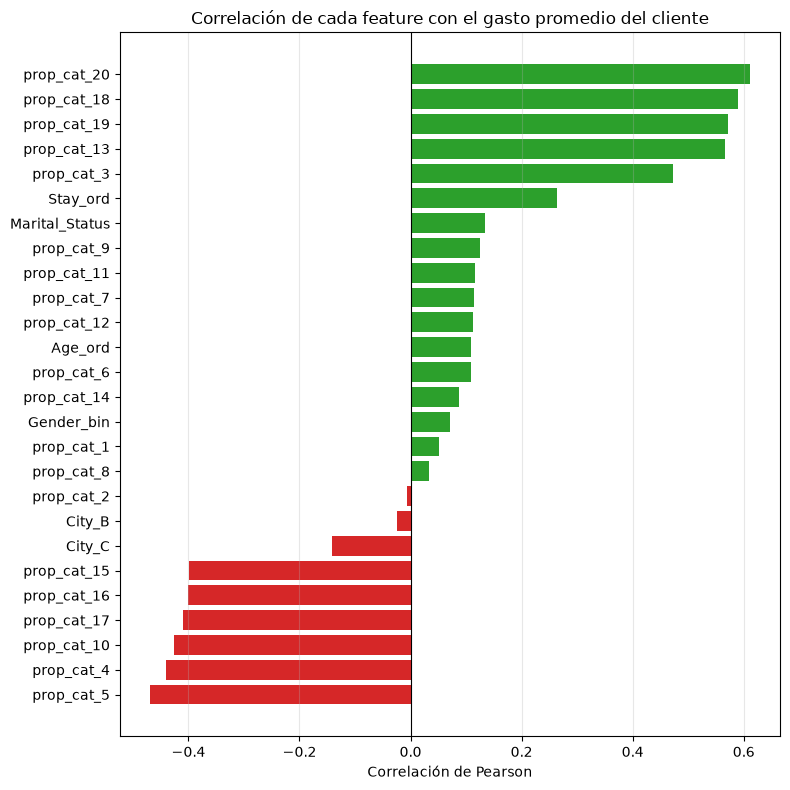

In [21]:
corr = datos_clientes.corr()["avg_purchase"].drop("avg_purchase").sort_values()
plt.figure(figsize=(8, 8))
plt.barh(corr.index, corr.values, color=np.where(corr.values > 0, "tab:green", "tab:red"))
plt.axvline(0, color="black", lw=0.8)
plt.title("Correlación de cada feature con el gasto promedio del cliente")
plt.xlabel("Correlación de Pearson"); plt.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

Las correlaciones confirman lo que anticipaba el EDA:

- **Las más positivas** son las proporciones de las categorías caras (20, 18, 19 y 13, de ≈\$21.000 por transacción, y la 3).
- **Las más negativas** son las categorías baratas (5, 4, 10, 17, 16 y 15: menos de \$1.000).
- **Las demográficas** tienen correlaciones chicas; la mayor es `Stay_ord` (0,26).

Hay una razón matemática para que las proporciones funcionen tan bien. Si $p_{u,c}$ es la proporción de compras del cliente $u$ en la categoría $c$ y $\bar{P}_c$ es el precio típico de esa categoría, el gasto promedio del cliente es aproximadamente $\sum_c p_{u,c}\,\bar{P}_c$. Es decir, **una combinación lineal de las proporciones**. Lo único que no captura esa fórmula es la variación de precios dentro de cada categoría, que en la mayoría es chica frente a la diferencia entre categorías.

### ¿Qué features dependen de cuántas compras acumuló el cliente?

El objetivo dice que el modelo se va a usar con clientes relativamente nuevos, con pocas compras. Entonces las features no deberían depender de *cuántas* compras hizo el cliente, sino de *qué* compra. Para decidirlo con datos medimos dos cosas en cada feature candidata:

1. Su correlación con `n_transactions`.
2. Cuánto cambia su valor si se la estima con pocas compras. Para eso tomamos 5 transacciones al azar de cada cliente y recalculamos la feature. **Esto es solo un diagnóstico**: el modelo se entrena siempre con todas las compras disponibles.

In [22]:
# 5 transacciones al azar por cliente: barajamos una vez y tomamos las primeras 5 de cada uno
muestra_5 = df.sample(frac=1.0, random_state=0).groupby("User_ID", sort=False).head(5)
prop_5 = features_comportamiento(muestra_5)
perfil_5 = features_perfil(prop_5)
volumen_5 = features_volumen(muestra_5)

filas = []
def corr(a, b):
    # np.corrcoef devuelve NaN (y avisa) si alguna de las dos series es constante
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    return np.corrcoef(a, b)[0, 1]

def comparar_feature(nombre, completa, con_5):
    filas.append({
        "Feature": nombre,
        "Correlación con n_transactions": corr(completa, volumen["n_transactions"]),
        "Valor medio (historial completo)": completa.mean(),
        "Valor medio (estimada con 5 compras)": con_5.mean(),
        "Correlación entre ambas versiones": corr(completa, con_5),
    })

comparar_feature("n_transactions", volumen["n_transactions"], volumen_5["n_transactions"])
comparar_feature("n_unique_categories", volumen["n_unique_categories"], volumen_5["n_unique_categories"])
comparar_feature("diversidad_categorias (entropía)", perfil["diversidad_categorias"], perfil_5["diversidad_categorias"])
comparar_feature("prop_categoria_favorita", perfil["prop_categoria_favorita"], perfil_5["prop_categoria_favorita"])
for c_ in ["prop_cat_3", "prop_cat_5", "prop_cat_20"]:
    comparar_feature(c_, comportamiento[c_], prop_5[c_])

display(pd.DataFrame(filas).round(3))
print("Promedio sobre las 20 proporciones:")
print(f"  correlación con n_transactions: {np.mean([abs(corr(comportamiento[c_], volumen['n_transactions'])) for c_ in comportamiento.columns]):.3f} (en valor absoluto)")
print(f"  diferencia de medias entre ambas versiones: {np.mean([abs(comportamiento[c_].mean() - prop_5[c_].mean()) for c_ in comportamiento.columns]):.4f}")

,Feature,Correlación con n_transactions,Valor medio (historial completo),Valor medio (estimada con 5 compras),Correlación entre ambas versiones
0,n_transactions,1.000,24.586,5.000,NaN
1,n_unique_categories,0.910,11.683,4.327,0.142
2,diversidad_categorias (entropía),0.812,0.757,0.473,0.206
3,prop_categoria_favorita,-0.490,0.204,0.322,0.249
4,prop_cat_3,0.389,0.094,0.092,0.545
5,prop_cat_5,-0.384,0.064,0.064,0.630
6,prop_cat_20,0.345,0.039,0.038,0.552


Promedio sobre las 20 proporciones:
  correlación con n_transactions: 0.220 (en valor absoluto)
  diferencia de medias entre ambas versiones: 0.0010


La tabla separa dos grupos con mucha claridad:

**Features que dependen del volumen (las descartamos):**

- `n_transactions`: por definición, correlación 1 con sí misma y valor medio 24,6 contra 5 en el escenario de pocas compras.
- `n_unique_categories`: correlación 0,91 con `n_transactions`. Pasa de 11,7 categorías distintas a 4,3 cuando se estima con 5 compras, y la correlación entre ambas versiones es de apenas 0,14. Es casi un contador disfrazado: con 5 compras no se pueden tener más de 5 categorías distintas.
- `diversidad_categorias` (entropía del mix) y `prop_categoria_favorita`: parecían buenos descriptores de perfil, pero tienen correlación 0,81 y −0,49 con `n_transactions`. La entropía cae de 0,757 a 0,473 y la concentración sube de 0,204 a 0,322 al estimarlas con pocas compras. Con pocos datos, todo cliente parece más concentrado y menos diverso de lo que realmente es, sin importar su perfil. Un modelo que se apoye en ellas recibiría, para un cliente nuevo, features corridas respecto de las que vio en entrenamiento: un cambio de distribución que no se corrige conociendo solo el mix.

**Proporciones por categoría (las que usamos):** su valor medio prácticamente no cambia (por ejemplo, `prop_cat_3` pasa de 0,094 a 0,092; en promedio sobre las 20 proporciones la diferencia es de 0,001). Son un estimador **insesgado** del mix del cliente: con pocas compras son más ruidosas, pero no se corren hacia un lado. Por eso un modelo entrenado con las proporciones del historial completo puede aplicarse a un cliente nuevo sin que las features cambien de escala.

Vale aclarar que las proporciones no son independientes de `n_transactions` (la correlación media es 0,22 en valor absoluto). Eso ocurre porque en este dataset los clientes que compran más también compran en categorías distintas, o sea que el mix y el volumen están relacionados. Pero eso es información sobre **qué** compra el cliente, que es justamente lo que queremos, y no una medida de cuánto acumuló.

Aclaración sobre el método: el muestreo de 5 transacciones se usó **solo para este diagnóstico**. El modelo se entrena con todas las compras de cada cliente, como corresponde, porque el dataset no tiene fecha y no hay manera de saber cuáles fueron las primeras.

### Data leakage: qué features NO usamos y por qué

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

SEED = 42
# Split por CLIENTE: 70% train, 15% validation, 15% test (cada cliente queda en un solo conjunto)
ids = datos_clientes.index.values
ids_train, ids_tmp = train_test_split(ids, test_size=0.30, random_state=SEED)
ids_val, ids_test = train_test_split(ids_tmp, test_size=0.50, random_state=SEED)
print(f"Clientes -> train: {len(ids_train)} | validation: {len(ids_val)} | test: {len(ids_test)}")

def r2_regresion_lineal(X):
    # baseline rápido: regresión lineal entrenada en train y evaluada en validation
    sc = StandardScaler().fit(X.loc[ids_train])
    lr_ = LinearRegression().fit(sc.transform(X.loc[ids_train]), target.loc[ids_train])
    return r2_score(target.loc[ids_val], lr_.predict(sc.transform(X.loc[ids_val])))

g = df.groupby("User_ID")
gasto_cat = df.pivot_table(index="User_ID", columns="Product_Category", values="Purchase", aggfunc="sum", fill_value=0)
leak_prop_gasto = gasto_cat.div(gasto_cat.sum(axis=1), axis=0).add_prefix("prop_gasto_cat_")
leak_gasto_total = g["Purchase"].sum().rename("gasto_total")
precio_producto = df.groupby("Product_ID")["Purchase"].transform("mean")
leak_precio_medio = df.assign(p=precio_producto).groupby("User_ID")["p"].mean().rename("precio_medio_productos")

subcat1 = pd.crosstab(df["User_ID"], df["Product_Subcategory_1"].fillna(0).astype(int)).pipe(lambda t: t.div(t.sum(axis=1), axis=0)).add_prefix("prop_sub1_")
subcat2 = pd.crosstab(df["User_ID"], df["Product_Subcategory_2"].fillna(0).astype(int)).pipe(lambda t: t.div(t.sum(axis=1), axis=0)).add_prefix("prop_sub2_")
conteos_cat = pd.crosstab(df["User_ID"], df["Product_Category"]).add_prefix("cnt_cat_")

X_base = datos_clientes[feature_cols]
favorita_oh = pd.get_dummies(df.groupby("User_ID")["Product_Category"].agg(lambda s: s.value_counts().idxmax()), prefix="favorita").astype(int)
experimentos = {
    "Solo demografía": demografia,
    "VOLUMEN: solo n_transactions y n_unique_*": volumen,
    "VOLUMEN: demografía + n_transactions y n_unique_*": demografia.join(volumen),
    "Demografía + CONTEOS por categoría": demografia.join(conteos_cat),
    "Demografía + PROPORCIONES por categoría": demografia.join(comportamiento.filter(like="prop_cat_")),
    "Features elegidas (demografía + proporciones)": X_base,
    "Elegidas + VOLUMEN (descartadas)": X_base.join(volumen),
    "Elegidas + entropía y concentración (descartadas)": X_base.join(perfil),
    "Elegidas + one-hot de categoría favorita": X_base.join(favorita_oh),
    "Elegidas + proporciones de subcategorías 1 y 2 (nulo = 0)": X_base.join(subcat1).join(subcat2),
    "LEAKAGE: elegidas + proporción de GASTO por categoría": X_base.join(leak_prop_gasto),
    "LEAKAGE: elegidas + gasto total del cliente": X_base.join(leak_gasto_total),
    "LEAKAGE: elegidas + precio medio de los productos comprados": X_base.join(leak_precio_medio),
}
pd.set_option("display.max_colwidth", 80)
tabla_leak = pd.DataFrame([{"Features": k, "Cantidad": v.shape[1], "R² val (regresión lineal)": round(r2_regresion_lineal(v), 4)}
                           for k, v in experimentos.items()])
tabla_leak

Clientes -> train: 5202 | validation: 1115 | test: 1115


,Features,Cantidad,R² val (regresión lineal)
0,Solo demografía,6,0.2838
1,VOLUMEN: solo n_transactions y n_unique_*,3,0.4392
2,VOLUMEN: demografía + n_transactions y n_unique_*,9,0.4725
3,Demografía + CONTEOS por categoría,26,0.8759
4,Demografía + PROPORCIONES por categoría,26,0.9403
5,Features elegidas (demografía + proporciones),26,0.9403
6,Elegidas + VOLUMEN (descartadas),29,0.9409
7,Elegidas + entropía y concentración (descartadas),28,0.9407
8,Elegidas + one-hot de categoría favorita,46,0.9404
9,Elegidas + proporciones de subcategorías 1 y 2 (nulo = 0),77,0.9436


Usamos una regresión lineal como baseline rápido: entrenada con los clientes de train y evaluada con los de validation. La red se entrena recién en 2b.

**Features legítimas:**

- **Solo demografía:** R² = 0,284. Confirma que quién es el cliente explica poco.
- **Solo volumen:** 0,439, y con demografía, 0,473. Un modelo basado en cuántas compras acumuló el cliente predice bastante, y es exactamente el atajo que queremos evitar.
- **Conteos vs. proporciones por categoría:** con conteos, 0,876; con proporciones, **0,940**. El conteo mezcla dos cosas, *cuánto* compra el cliente y *qué* compra. La proporción aísla el mix.
- **Features elegidas (demografía + proporciones):** 0,940.
- **Agregar volumen a las elegidas:** 0,941. Es decir, la información de cuántas compras hizo el cliente **no aporta prácticamente nada** una vez que se conoce su mix de categorías (+0,0006). Descartarla no cuesta desempeño y hace al modelo utilizable con clientes nuevos.
- **Entropía y concentración:** 0,941, y el one-hot de la categoría favorita, 0,940. Tampoco aportan sobre las proporciones, que ya contienen esa información: la categoría favorita es aquella en la que la proporción es más alta (el argmax de las 20 columnas).

**Features con leakage, que descartamos.** La consigna advierte que el leakage "ocurre mucho cuando se usan proporciones como nuevas columnas", y el experimento lo muestra:

- **Proporción de GASTO por categoría** (gasto en la categoría / gasto total): 0,956. Parece la misma idea que nuestras proporciones, pero su denominador es el gasto total del cliente, que es el target multiplicado por la cantidad de transacciones. La feature ya trae información del monto que queremos predecir.
- **Gasto total del cliente:** 0,947. Y si además estuviera `n_transactions` entre las features, una red podría aprender la división gasto_total / n_transactions y reconstruir el target exacto.
- **Precio medio de los productos comprados** (promedio de `Purchase` por producto sobre todo el dataset): **R² = 1,000**. Como cada producto tiene un precio fijo, esta feature *es* el target calculado de otra forma. Además, al calcular el precio de cada producto con transacciones de todos los clientes, usa información de los clientes de validation y test (leakage entre conjuntos).

**Las proporciones que usamos no tienen este problema.** Se calculan contando transacciones, sin tocar `Purchase`, y cada una usa solo las compras de ese cliente, sin información de otros clientes ni de otros conjuntos. Además, el split se hace por cliente y los escaladores se ajustan solo con train (en 2b).

### Conclusiones preliminares de 2a

- **Unidad de análisis:** el cliente. Agregamos las 182.721 transacciones en 7.432 filas, usando **todas** las compras de cada cliente, con el target = gasto promedio.
- **Features finales (26):**
  - 6 demográficas codificadas (ordinal para Age y Stay, mapping para Gender, 0/1 para Marital_Status, one-hot para City);
  - 20 proporciones de transacciones por `Product_Category`.
- **Descartadas:** `User_ID` y `Product_ID` como features; las dos subcategorías (nulos estructurales con aporte marginal); todo lo derivado de `Purchase` (leakage); y todas las variables que dependen de cuántas compras acumuló el cliente (`n_transactions`, `n_unique_products`, `n_unique_categories`, entropía y concentración del mix).
- **Lo que determina el gasto** es el mix de categorías que compra el cliente, porque el precio lo fija el producto. Las variables demográficas aportan poco.
- **Split:** por cliente, 70% train (5.202), 15% validation (1.115) y 15% test (1.115). Test no interviene en ninguna decisión del modelo (pesos, escaladores, hiperparámetros ni época elegida) y recién se evalúa en 2c. El EDA de esta sección sí mira el dataset completo, como es habitual.
- **Punto de partida:** una regresión lineal con estas features ya da R² = 0,940 en validation, así que el problema es casi lineal. Esperamos que el MLP mejore poco sobre eso.

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

In [24]:
import copy
import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

X_train_np = datos_clientes.loc[ids_train, feature_cols].values.astype(np.float32)
X_val_np = datos_clientes.loc[ids_val, feature_cols].values.astype(np.float32)
X_test_np = datos_clientes.loc[ids_test, feature_cols].values.astype(np.float32)
y_train_np = target.loc[ids_train].values.astype(np.float32).reshape(-1, 1)
y_val_np = target.loc[ids_val].values.astype(np.float32).reshape(-1, 1)
y_test_np = target.loc[ids_test].values.astype(np.float32).reshape(-1, 1)

# Escaladores ajustados SOLO con train (evita filtrar información de validation/test)
x_scaler = StandardScaler().fit(X_train_np)
y_scaler = StandardScaler().fit(y_train_np)

def a_tensor(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

Xtr, Xva, Xte = (a_tensor(x_scaler.transform(a)) for a in (X_train_np, X_val_np, X_test_np))
ytr, yva, yte = (a_tensor(y_scaler.transform(a)) for a in (y_train_np, y_val_np, y_test_np))
print("Train:", tuple(Xtr.shape), "| Val:", tuple(Xva.shape), "| Test:", tuple(Xte.shape))

device: cpu
Train: (5202, 26) | Val: (1115, 26) | Test: (1115, 26)


### Estrategia de búsqueda de hiperparámetros

Adaptamos el esquema de entrenamiento de la clase 3 (`nn.Sequential`, `DataLoader`, Adam y MSE) a una configuración inicial que cumpla el mínimo de la consigna: 3 capas ocultas `[64, 64, 32]`, ReLU, Adam con `lr=1e-3`, MSE y batch de 64. Las arquitecturas de la clase 3 son otras (`2→32→16→1` para el caso físico y `784→128→64→10` para MNIST), así que el punto de partida es nuestro, no una copia. Desde ahí variamos **un factor por vez**, nos quedamos con el mejor y pasamos al siguiente:

1. activación → 2. optimizador → 3. learning rate → 4. función de costo → 5. batch size → 6. arquitectura → 7. regularización → número de épocas.

No es una grilla exhaustiva (serían miles de combinaciones), pero cada decisión queda respaldada por una comparación. Para no elegir por azar:

- **Cada variante se entrena con 3 semillas** y reportamos la media y el desvío.
- **El criterio es el R² de validación en la mejor época**, porque el modelo final entrena todas las épocas y después restaura los pesos de la época con mejor validación (selección del mejor checkpoint, sin detención anticipada).
- **También mostramos el R² en la época 60**, que indica qué tan rápido se degrada el modelo si se sigue entrenando (sobreajuste).
- **Test no se toca** durante la búsqueda.

**Regla de decisión.** Varias etapas terminan con diferencias de R² del orden del desvío entre semillas, que en nuestras tablas va de 0,0001 a 0,0010. Elegir la ganadora en esos casos sería quedarse con ruido, así que fijamos una regla antes de empezar y la aplicamos igual en las siete etapas:

> Partimos de una **configuración de referencia** y solo nos movemos de ella cuando la mejora alcanza o supera **0,001 de R²**, que es el orden de magnitud del ruido entre semillas. Si la mejor variante le gana a la referencia por menos que eso, nos quedamos con la referencia.

Es un **umbral práctico de mejora**, no una regla estadística: no probamos que las diferencias menores a 0,001 sean ruido, sino que las tratamos como tales porque son del mismo orden que la dispersión que vemos entre semillas. (La regla de *un error estándar* de la literatura usa el error estándar estimado por validación cruzada, que no es lo que hacemos acá.) La idea de fondo sí es la misma: ante un empate técnico, preferir la opción más simple o más estándar.

**La configuración de referencia es nuestra**, armada adaptando lo que vimos en clase: ReLU y Adam salen del notebook de la clase 3, `lr=1e-3` es el valor por defecto de Adam (y el que usa el ejemplo de MNIST de esa clase), MSE es lo que indica la clase 2 para regresión, y el batch 64 y la arquitectura `[64, 64, 32]` los elegimos nosotros para cumplir el mínimo de la consigna. El ejemplo de regresión de la clase 3 usa otros valores (`lr=1e-2`, batch 256, RMSE y una red `2→32→16→1`), así que no es una copia. La consecuencia práctica es que **cada desvío respecto de la clase queda respaldado por una diferencia medible**, y no por el cuarto decimal. El código imprime cuándo se activa la regla.

In [25]:
ACTIVACIONES = {"relu": nn.ReLU, "leaky_relu": nn.LeakyReLU, "tanh": nn.Tanh, "sigmoid": nn.Sigmoid, "gelu": nn.GELU}
PERDIDAS = {"mse": nn.MSELoss, "l1": nn.L1Loss, "huber": nn.HuberLoss}

def crear_mlp(n_in, capas_ocultas, activacion, dropout):
    capas, prev = [], n_in
    for h in capas_ocultas:
        capas += [nn.Linear(prev, h), ACTIVACIONES[activacion]()]   # cada capa oculta con su activación
        if dropout > 0:
            capas.append(nn.Dropout(dropout))
        prev = h
    capas.append(nn.Linear(prev, 1))    # regresión: 1 neurona de salida sin activación
    return nn.Sequential(*capas)

def crear_optimizador(nombre, params, lr, weight_decay):
    if nombre == "sgd":
        return torch.optim.SGD(params, lr=lr, weight_decay=weight_decay)
    if nombre == "sgd_momentum":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay)
    if nombre == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)

def entrenar(cfg, epochs, seed, guardar_mejor=False):
    torch.manual_seed(seed)
    modelo = crear_mlp(Xtr.shape[1], cfg["capas"], cfg["activacion"], cfg["dropout"]).to(device)
    opt = crear_optimizador(cfg["optimizador"], modelo.parameters(), cfg["lr"], cfg["weight_decay"])
    perdida = PERDIDAS[cfg["perdida"]]()
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=cfg["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    hist = {"train_loss": [], "val_loss": [], "train_r2": [], "val_r2": []}
    mejor = {"val_r2": -np.inf, "epoca": -1, "estado": None}
    for epoca in range(epochs):
        modelo.train()                          # activa dropout
        for xb, yb in loader:
            opt.zero_grad()
            loss = perdida(modelo(xb), yb)
            loss.backward()
            opt.step()
        modelo.eval()                           # desactiva dropout para medir
        with torch.no_grad():
            p_tr, p_va = modelo(Xtr), modelo(Xva)
            hist["train_loss"].append(perdida(p_tr, ytr).item())
            hist["val_loss"].append(perdida(p_va, yva).item())
            hist["train_r2"].append(r2_score(ytr.cpu().numpy(), p_tr.cpu().numpy()))
            hist["val_r2"].append(r2_score(yva.cpu().numpy(), p_va.cpu().numpy()))
        if hist["val_r2"][-1] > mejor["val_r2"]:
            mejor.update(val_r2=hist["val_r2"][-1], epoca=epoca + 1)
            if guardar_mejor:
                mejor["estado"] = copy.deepcopy(modelo.state_dict())
    return modelo, hist, mejor

SEEDS = [0, 1, 2]
EPOCHS_BUSQUEDA = 60

TOL_RUIDO = 0.001   # diferencias de R² menores a esto están en el orden del desvío entre semillas

def comparar(variantes, base, titulo, referencia=None):
    # entrena cada variante con 3 semillas y resume el R² de validación
    filas, curvas = [], {}
    t0 = time.time()
    for etiqueta, cambios in variantes.items():
        cfg = {**base, **cambios}
        mejores, finales, epocas, vr2 = [], [], [], []
        for s in SEEDS:
            _, h, m = entrenar(cfg, EPOCHS_BUSQUEDA, s)
            mejores.append(m["val_r2"]); finales.append(h["val_r2"][-1]); epocas.append(m["epoca"]); vr2.append(h["val_r2"])
        curvas[etiqueta] = np.mean(vr2, axis=0)
        filas.append({"Variante": etiqueta,
                      "R² val mejor época (media)": np.mean(mejores), "± desvío": np.std(mejores),
                      "Mejor época (media)": np.mean(epocas),
                      f"R² val época {EPOCHS_BUSQUEDA} (media)": np.mean(finales)})
    tabla = pd.DataFrame(filas)
    col = "R² val mejor época (media)"
    ganador = tabla.loc[tabla[col].idxmax(), "Variante"]        # sobre los valores sin redondear
    if referencia is not None and ganador != referencia:
        # Regla del desvío: si la mejora sobre la opción de referencia no supera el ruido, nos quedamos con la referencia
        brecha = tabla[col].max() - float(tabla.loc[tabla["Variante"] == referencia, col].iloc[0])
        if brecha < TOL_RUIDO:
            print(f"'{ganador}' supera a la referencia '{referencia}' por solo {brecha:.4f} (< {TOL_RUIDO}): "
                  f"la diferencia está dentro del ruido, así que nos quedamos con '{referencia}'.")
            ganador = referencia
    tabla = tabla.round(4)

    plt.figure(figsize=(9, 4))
    for etiqueta, c in curvas.items():
        plt.plot(np.arange(1, EPOCHS_BUSQUEDA + 1), c, label=etiqueta, lw=2 if etiqueta == ganador else 1.2)
    plt.ylim(max(0.5, min(c.min() for c in curvas.values())), None)
    plt.xlabel("Época"); plt.ylabel("R² validación (media de 3 semillas)")
    plt.title(titulo); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()
    print(f"({time.time() - t0:.0f}s)")
    return tabla, ganador

CONFIG = {"capas": [64, 64, 32], "activacion": "relu", "optimizador": "adam", "lr": 1e-3,
          "perdida": "mse", "batch_size": 64, "dropout": 0.0, "weight_decay": 0.0}
print("Configuración base:", CONFIG)

Configuración base: {'capas': [64, 64, 32], 'activacion': 'relu', 'optimizador': 'adam', 'lr': 0.001, 'perdida': 'mse', 'batch_size': 64, 'dropout': 0.0, 'weight_decay': 0.0}


#### Etapa 1: función de activación de las capas ocultas

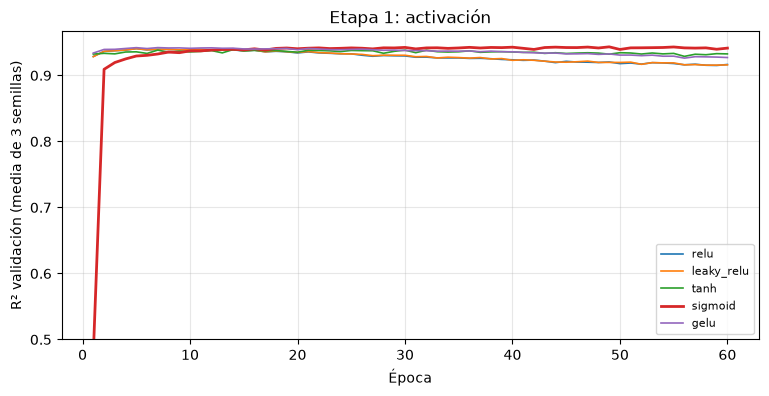

(41s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,relu,0.9414,0.0006,6.0000,0.9166
1,leaky_relu,0.9412,0.0003,6.0000,0.9159
2,tanh,0.9403,0.0007,23.0000,0.9326
3,sigmoid,0.9434,0.0003,49.6667,0.9414
4,gelu,0.9427,0.0007,7.3333,0.9271


Elegida: sigmoid


In [26]:
variantes = {a: {"activacion": a} for a in ["relu", "leaky_relu", "tanh", "sigmoid", "gelu"]}
tabla_act, ganador = comparar(variantes, CONFIG, "Etapa 1: activación", referencia="relu")
display(tabla_act)
CONFIG["activacion"] = ganador
print("Elegida:", ganador)

Las cinco activaciones quedan dentro de 0,0031 de R² (0,9403 a 0,9434), pero se comportan distinto a lo largo del entrenamiento:

- **ReLU, Leaky ReLU y GELU** llegan a su mejor valor muy rápido (época 6 a 7) y después se degradan en validación: en la época 60 están entre 0,916 y 0,927. Aprenden rápido, y a partir de ahí lo que ganan en train deja de traducirse en validación (no medimos el R² de train de estas variantes, así que lo describimos por lo que se ve en la curva de validación).
- **Tanh** tarda más (época 23) y queda un poco por debajo.
- **Sigmoid** es la más lenta en llegar (época ≈50) pero alcanza el mejor valor (0,9434, desvío 0,0003) y es la más estable (0,9414 en la época 60).

**Sigmoid supera a la referencia (ReLU) por 0,0020, el doble del umbral de 0,001**, así que la regla del umbral habilita el cambio: esta es una de las dos únicas etapas donde nos apartamos de la configuración base. Conviene explicar por qué va contra lo que se recomienda en general. En la clase 2 vimos que en capas ocultas la sigmoid se satura, tiene gradientes chicos (vanishing gradient) y entrena lento, y que ReLU es el default habitual. Nuestra hipótesis para explicar lo que medimos: esos problemas pesan sobre todo en redes profundas, y acá hay solo 3 capas ocultas y entradas estandarizadas; además Adam ayuda, porque su paso no escala con la magnitud del gradiente. Y en un problema casi lineal (la regresión lineal ya da 0,940), aprender más despacio actúa como una regularización implícita: el modelo tarda más en empezar a memorizar el train, que es justo lo que se ve en la curva. La diferencia con ReLU es chica, aunque varias veces el desvío entre semillas; es evidencia de esta configuración y este split, no una regla general a favor de la sigmoid.

#### Etapa 2: algoritmo de optimización

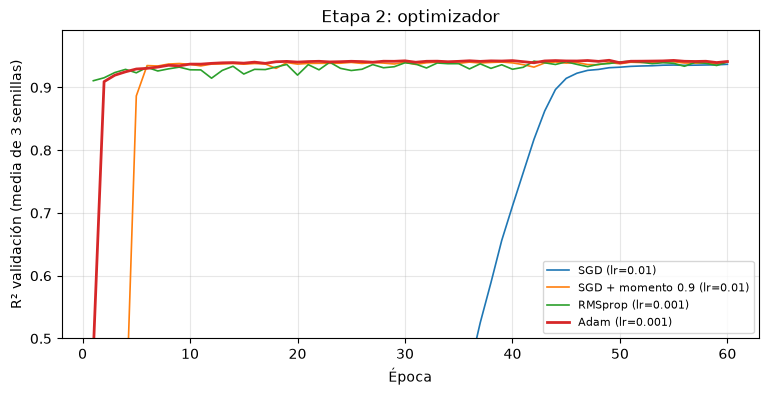

(24s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,SGD (lr=0.01),0.9369,0.0009,60.0000,0.9369
1,SGD + momento 0.9 (lr=0.01),0.9416,0.0002,56.0000,0.9408
2,RMSprop (lr=0.001),0.9434,0.0005,53.0000,0.9406
3,Adam (lr=0.001),0.9434,0.0003,49.6667,0.9414


Elegido: Adam (lr=0.001)


In [27]:
variantes = {
    "SGD (lr=0.01)":                {"optimizador": "sgd", "lr": 1e-2},
    "SGD + momento 0.9 (lr=0.01)":  {"optimizador": "sgd_momentum", "lr": 1e-2},
    "RMSprop (lr=0.001)":           {"optimizador": "rmsprop", "lr": 1e-3},
    "Adam (lr=0.001)":              {"optimizador": "adam", "lr": 1e-3},
}
tabla_opt_mlp, ganador = comparar(variantes, CONFIG, "Etapa 2: optimizador", referencia="Adam (lr=0.001)")
display(tabla_opt_mlp)
CONFIG.update(variantes[ganador])
print("Elegido:", ganador)

El orden coincide con lo visto en la clase 2:

| Optimizador | R² val (mejor época) | Comportamiento |
|---|---|---|
| SGD (`lr=0.01`) | 0,9369 | Sigue mejorando en la época 60: no terminó de converger |
| SGD + momento 0,9 | 0,9416 | Acelera claramente a SGD, porque el momento acumula la dirección de bajada |
| RMSprop | 0,9434 | Adaptativo, prácticamente empatado con Adam |
| **Adam** | **0,9434** | El mejor valor y el más estable en la época 60 (0,9414) |

La diferencia entre RMSprop y Adam es de 4·10⁻⁵, casi diez veces menos que el desvío entre semillas (0,0003 a 0,0005): **este experimento no permite distinguirlos**, y cualquiera de los dos habría sido una elección razonable. Acá la regla del umbral ni siquiera hace falta, porque la referencia (Adam) es directamente la ganadora, y además es la más estable al final del entrenamiento.

Lo que sí se ve, con este presupuesto de 60 épocas, es la ventaja de los métodos adaptativos sobre SGD y la del momento sobre SGD puro. Con más épocas la diferencia podría achicarse: SGD todavía estaba mejorando en la última época, así que el experimento compara velocidad de convergencia, no un techo de calidad.

#### Etapa 3: learning rate

'lr=0.003' supera a la referencia 'lr=0.001' por solo 0.0006 (< 0.001): la diferencia está dentro del ruido, así que nos quedamos con 'lr=0.001'.


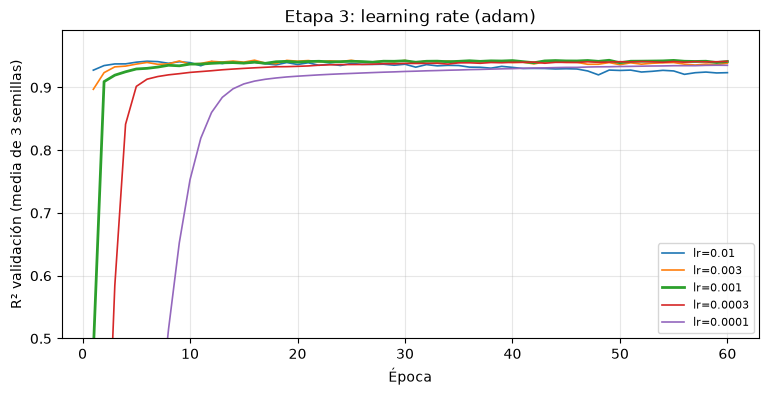

(37s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,lr=0.01,0.9430,0.0003,10.6667,0.9235
1,lr=0.003,0.9440,0.0002,16.3333,0.9386
2,lr=0.001,0.9434,0.0003,49.6667,0.9414
3,lr=0.0003,0.9418,0.0003,59.0000,0.9416
4,lr=0.0001,0.9355,0.0010,59.6667,0.9352


Elegido: lr=0.001


In [28]:
variantes = {f"lr={lr}": {"lr": lr} for lr in [1e-2, 3e-3, 1e-3, 3e-4, 1e-4]}
tabla_lr, ganador = comparar(variantes, CONFIG, f"Etapa 3: learning rate ({CONFIG['optimizador']})", referencia="lr=0.001")
display(tabla_lr)
CONFIG.update(variantes[ganador])
print("Elegido:", ganador)

- **`lr=0.01`:** llega al pico muy rápido (época 11) pero después se desploma (0,9235 en la época 60): pasos demasiado grandes.
- **`lr=0.003`:** el mejor valor de la tabla (0,9440).
- **`lr=0.001`:** 0,9434, o sea 0,0006 menos, y muy estable al final del entrenamiento (0,9414 en la época 60, a 0,0002 del máximo de esa columna, que lo tiene `lr=0.0003` justamente porque todavía no llegó a su pico).
- **`lr=0.0003` y `lr=0.0001`:** a la época 60 todavía están subiendo (0,9416 y 0,9352): demasiado lentos para este presupuesto.

**Se activa la regla del umbral:** `lr=0.003` le gana a la referencia por 0,0006, menos que el umbral de 0,001, así que **nos quedamos con `lr=0.001`**, que además es el valor por defecto de Adam y el que usa el notebook de la clase 3. El costo de esa decisión es que el entrenamiento tarda más en llegar al pico (época ≈50 en vez de ≈16), lo cual no es un problema porque después restauramos la mejor época.

#### Etapa 4: función de costo

'MAE (L1)' supera a la referencia 'MSE' por solo 0.0003 (< 0.001): la diferencia está dentro del ruido, así que nos quedamos con 'MSE'.


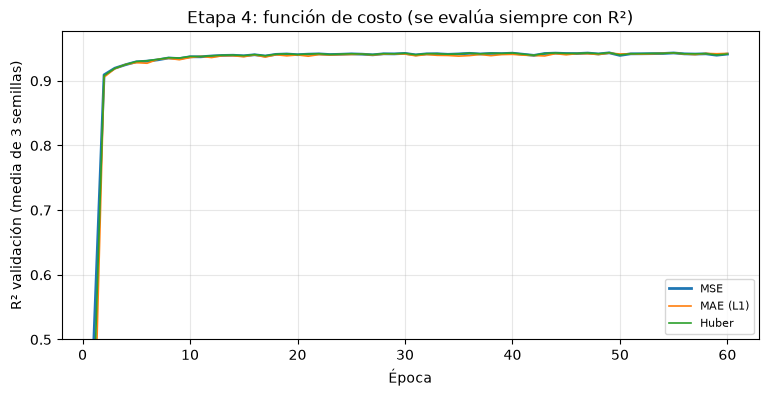

(22s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,MSE,0.9434,0.0003,49.6667,0.9414
1,MAE (L1),0.9437,0.0001,50.3333,0.9424
2,Huber,0.9437,0.0001,48.3333,0.9414


Elegida: MSE


In [29]:
variantes = {"MSE": {"perdida": "mse"}, "MAE (L1)": {"perdida": "l1"}, "Huber": {"perdida": "huber"}}
tabla_loss, ganador = comparar(variantes, CONFIG, "Etapa 4: función de costo (se evalúa siempre con R²)", referencia="MSE")
display(tabla_loss)
CONFIG.update(variantes[ganador])
print("Elegida:", ganador)

Las tres pérdidas quedan dentro de 0,0003 (0,9434 a 0,9437), con desvíos entre semillas de 0,0001 a 0,0003. **Se activa la regla del umbral y nos quedamos con MSE.**

La decisión coincide con lo que dice la teoría, y eso es lo importante acá:

- **MSE es la pérdida estándar de regresión** (clase 2) y está directamente ligada a la métrica que pide la consigna: $R^2 = 1 - \text{MSE}/\text{Var}(y)$, así que minimizar MSE **es** maximizar R². Cualquier otra pérdida optimiza algo apenas distinto de lo que se evalúa.
- **El target no tiene outliers fuertes** (asimetría 0,54, máximo \$17.231), que es el escenario donde una pérdida robusta como MAE o Huber valdría la pena.

Además hay una razón por la que era previsible que empataran. Con el target estandarizado, casi todos los residuos son menores a 1 desvío (el RMSE final ronda 0,23 desvíos), y en esa zona la pérdida de Huber (δ=1, Huber 1964) es exactamente $\tfrac{1}{2}r^2$, o sea MSE salvo una constante; como Adam normaliza el paso, multiplicar la pérdida por una constante casi no cambia el entrenamiento. Solo difieren en los pocos clientes con residuos grandes, donde Huber crece de forma lineal y les da menos peso, y MAE trata todos los errores por igual.

#### Etapa 5: tamaño de batch

'batch=32' supera a la referencia 'batch=64' por solo 0.0007 (< 0.001): la diferencia está dentro del ruido, así que nos quedamos con 'batch=64'.


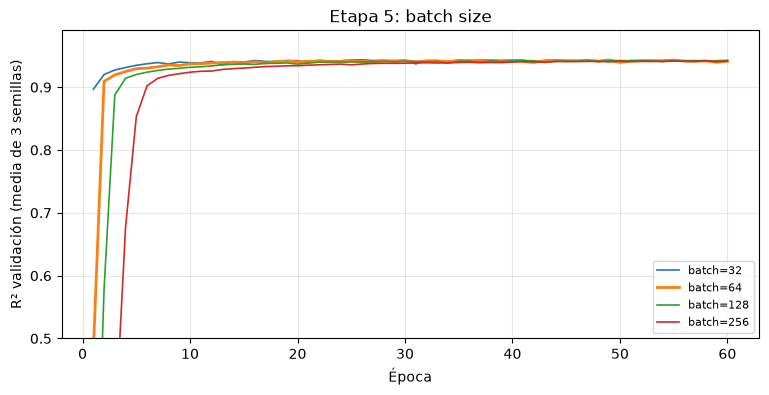

(28s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,batch=32,0.9441,0.0003,34.3333,0.9424
1,batch=64,0.9434,0.0003,49.6667,0.9414
2,batch=128,0.9434,0.0003,55.6667,0.9426
3,batch=256,0.9421,0.0002,59.3333,0.9416


Elegido: batch=64


In [30]:
variantes = {f"batch={b}": {"batch_size": b} for b in [32, 64, 128, 256]}
tabla_bs, ganador = comparar(variantes, CONFIG, "Etapa 5: batch size", referencia="batch=64")
display(tabla_bs)
CONFIG.update(variantes[ganador])
print("Elegido:", ganador)

- **batch = 32** da el mejor valor (0,9441) y llega antes al pico (época 34).
- **batch = 64 y 128** empatan en 0,9434.
- **batch = 256** queda último (0,9421) y a la época 60 todavía está mejorando (mejor época 59).

Con 5.202 clientes de entrenamiento, un batch de 32 hace 163 actualizaciones por época, uno de 64 hace 82, uno de 128 hace 41 y uno de 256 solo 21. Por eso cuanto más chico el batch, antes llega al pico: es el mismo efecto que vimos en la Pregunta 1 con Adam mini-batch.

**Se activa la regla del umbral:** batch 32 le gana a la referencia por 0,0007, por debajo del umbral, así que **nos quedamos con batch = 64**. Es también el tamaño de la configuración base y entrena más rápido que 32 en tiempo de cómputo.

#### Etapa 6: arquitectura (mínimo 3 capas ocultas de 32 neuronas)

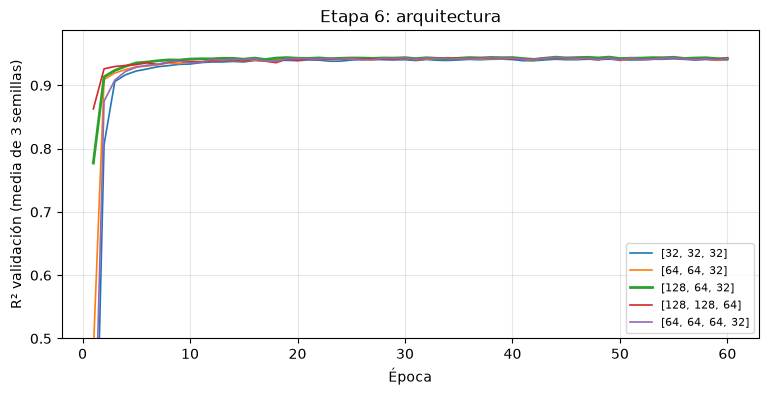

(41s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,"[32, 32, 32]",0.9424,0.0004,48.3333,0.9404
1,"[64, 64, 32]",0.9434,0.0003,49.6667,0.9414
2,"[128, 64, 32]",0.9449,0.0002,46.0000,0.9422
3,"[128, 128, 64]",0.9448,0.0001,48.3333,0.9437
4,"[64, 64, 64, 32]",0.9446,0.0003,41.3333,0.9424


Elegida: [128, 64, 32]


In [31]:
variantes = {str(c): {"capas": c} for c in [[32, 32, 32], [64, 64, 32], [128, 64, 32], [128, 128, 64], [64, 64, 64, 32]]}
tabla_arq, ganador = comparar(variantes, CONFIG, "Etapa 6: arquitectura", referencia="[64, 64, 32]")
display(tabla_arq)
CONFIG.update(variantes[ganador])
print("Elegida:", ganador)

Esta es la única etapa, además de la activación, donde la mejora supera el ruido:

- **`[32, 32, 32]`** (el mínimo que pide la consigna) queda último (0,9424).
- **`[64, 64, 32]`** (la referencia) da 0,9434.
- **`[128, 64, 32]`** da **0,9449**, o sea 0,0015 más que la referencia, por encima del umbral de 0,001 y con un desvío entre semillas de apenas 0,0002. **Se adopta.**
- **`[128, 128, 64]`** y la de cuatro capas no mejoran sobre esa (0,9448 y 0,9446), así que más capacidad no aporta.

**Elegimos `[128, 64, 32]`**: 3 capas ocultas, todas con 32 o más neuronas, en forma de embudo. Son 3.456 + 8.256 + 2.080 + 33 = 13.825 parámetros para 5.202 clientes de entrenamiento, bastante, y por eso miramos con atención la regularización en la próxima etapa.

#### Etapa 7: regularización (Dropout y L2 / weight decay)

'dropout 0.1' supera a la referencia 'sin regularización' por solo 0.0003 (< 0.001): la diferencia está dentro del ruido, así que nos quedamos con 'sin regularización'.


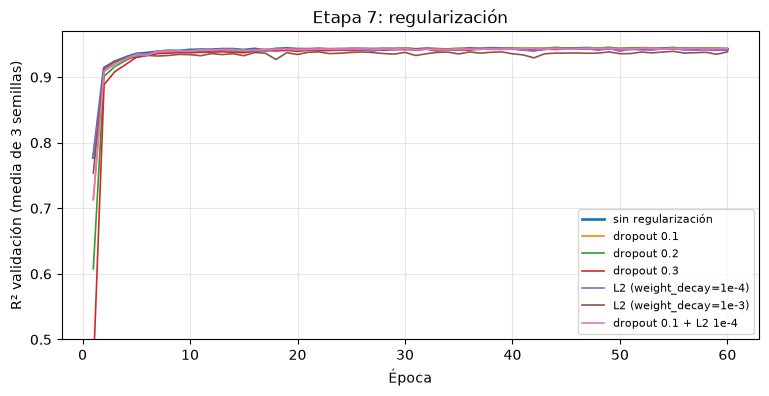

(65s)


,Variante,R² val mejor época (media),± desvío,Mejor época (media),R² val época 60 (media)
0,sin regularización,0.9449,0.0002,46.0000,0.9422
1,dropout 0.1,0.9452,0.0001,56.0000,0.9441
2,dropout 0.2,0.9447,0.0003,55.6667,0.9433
3,dropout 0.3,0.9440,0.0004,51.0000,0.9423
4,L2 (weight_decay=1e-4),0.9447,0.0001,48.3333,0.9431
5,L2 (weight_decay=1e-3),0.9398,0.0003,46.6667,0.9386
6,dropout 0.1 + L2 1e-4,0.9447,0.0002,59.0000,0.9437


Elegida: sin regularización

Configuración final: {'capas': [128, 64, 32], 'activacion': 'sigmoid', 'optimizador': 'adam', 'lr': 0.001, 'perdida': 'mse', 'batch_size': 64, 'dropout': 0.0, 'weight_decay': 0.0}


In [32]:
variantes = {
    "sin regularización":        {"dropout": 0.0, "weight_decay": 0.0},
    "dropout 0.1":               {"dropout": 0.1, "weight_decay": 0.0},
    "dropout 0.2":               {"dropout": 0.2, "weight_decay": 0.0},
    "dropout 0.3":               {"dropout": 0.3, "weight_decay": 0.0},
    "L2 (weight_decay=1e-4)":    {"dropout": 0.0, "weight_decay": 1e-4},
    "L2 (weight_decay=1e-3)":    {"dropout": 0.0, "weight_decay": 1e-3},
    "dropout 0.1 + L2 1e-4":     {"dropout": 0.1, "weight_decay": 1e-4},
}
tabla_reg, ganador = comparar(variantes, CONFIG, "Etapa 7: regularización", referencia="sin regularización")
display(tabla_reg)
CONFIG.update(variantes[ganador])
print("Elegida:", ganador)
print("\nConfiguración final:", CONFIG)

Probamos las dos técnicas de regularización de la clase 4: Dropout y L2 (`weight_decay` en el optimizador).

- **Dropout 0,1 da el mejor valor** (0,9452), apenas 0,0003 por encima de no regularizar (0,9449).
- **Dropout 0,2 y L2 = 1e-4** quedan en 0,9447, también dentro del ruido.
- **Dropout 0,3 y L2 = 1e-3 rinden peor** (0,9440 y 0,9398). Lo esperable es que regularicen de más, aunque no medimos el R² de entrenamiento de esas variantes, así que no podemos confirmarlo.
- **Donde sí se nota la regularización es en la estabilidad:** en la época 60, dropout 0,1 mantiene 0,9441 contra 0,9422 sin regularizar. No sube el techo, hace más lenta la caída cuando se entrena de más.

**Se activa la regla del umbral y nos quedamos sin regularización.** Es coherente con el resto del diseño: como el modelo final restaura la mejor época, el beneficio del dropout (aguantar más épocas sin degradarse) no se aprovecha. Si en cambio tuviéramos que entrenar un número fijo y alto de épocas, la elección correcta sería dropout 0,1.

#### Número de épocas

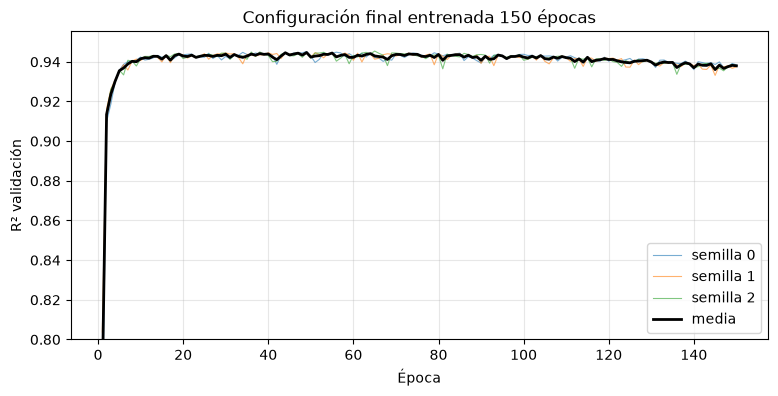

Mejor época por semilla: [49, 51, 65]
  época  10: R² val medio = 0.9415
  época  20: R² val medio = 0.9429
  época  30: R² val medio = 0.9439
  época  50: R² val medio = 0.9424
  época  75: R² val medio = 0.9438
  época 100: R² val medio = 0.9424
  época 150: R² val medio = 0.9380


In [33]:
EPOCHS_FINAL = 150
curvas_val, mejores_epocas = [], []
for s in SEEDS:
    _, h, m = entrenar(CONFIG, EPOCHS_FINAL, s)
    curvas_val.append(h["val_r2"]); mejores_epocas.append(m["epoca"])
curvas_val = np.array(curvas_val)
media = curvas_val.mean(axis=0)

plt.figure(figsize=(9, 4))
for s, c in zip(SEEDS, curvas_val):
    plt.plot(np.arange(1, EPOCHS_FINAL + 1), c, lw=0.8, alpha=0.6, label=f"semilla {s}")
plt.plot(np.arange(1, EPOCHS_FINAL + 1), media, color="black", lw=2, label="media")
plt.ylim(max(0.8, curvas_val.min()), None)
plt.xlabel("Época"); plt.ylabel("R² validación"); plt.title("Configuración final entrenada 150 épocas")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("Mejor época por semilla:", mejores_epocas)
for e in [10, 20, 30, 50, 75, 100, 150]:
    print(f"  época {e:>3}: R² val medio = {media[e - 1]:.4f}")

Entrenamos la configuración final durante 150 épocas con las 3 semillas para ver dónde conviene cortar:

| Época | 10 | 20 | 30 | 50 | 75 | 100 | 150 |
|---|---|---|---|---|---|---|---|
| R² val medio | 0,9415 | 0,9429 | **0,9439** | 0,9424 | 0,9438 | 0,9424 | 0,9380 |

Las mejores épocas por semilla son 49, 51 y 65. La curva sube rápido, entra en una meseta ruidosa entre las épocas 30 y 100, y recién después baja de forma clara (0,9380 en la 150). **La zona razonable está entre las épocas 30 y 75.**

Comparado con configuraciones de learning rate más alto que probamos en la etapa 3, la degradación acá es mucho más suave: con `lr=0.001` el modelo se deteriora despacio, que es otra ventaja de la elección de esa etapa. Igual, en vez de fijar un número a mano, en 2c entrenamos las 150 épocas completas y nos quedamos con los pesos de la época con mejor R² de validación.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

Mejor época: 49 | R² val = 0.9452 | R² val en la última época = 0.9385


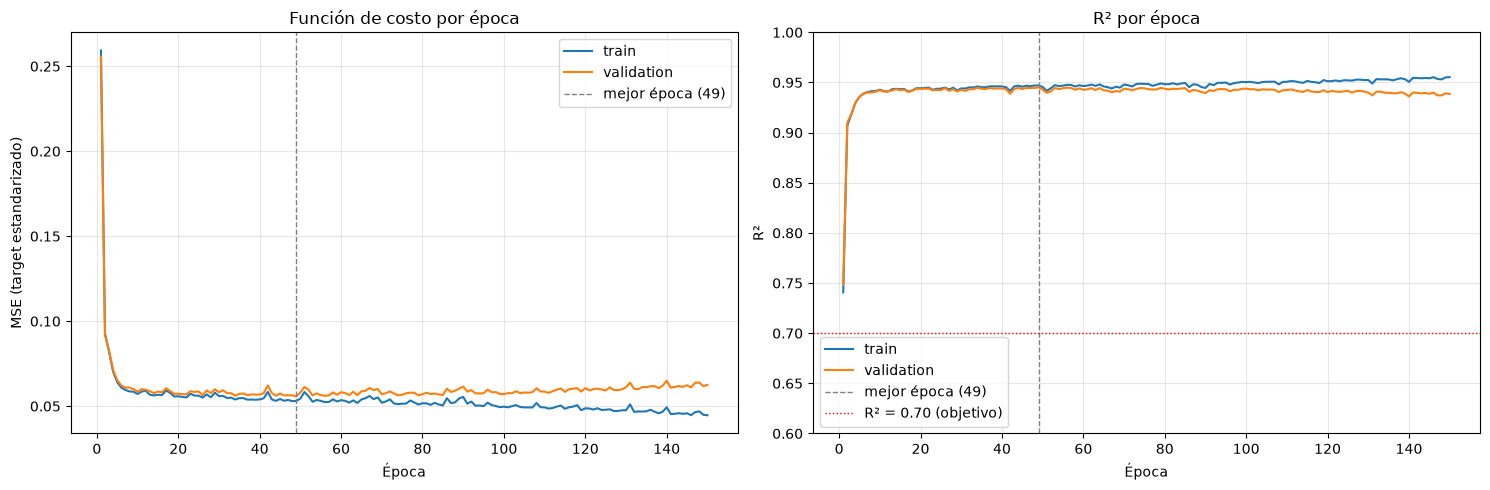

In [34]:
SEED_FINAL = 0
modelo, hist, mejor = entrenar(CONFIG, EPOCHS_FINAL, SEED_FINAL, guardar_mejor=True)
modelo.load_state_dict(mejor["estado"])     # nos quedamos con los pesos de la mejor época en validation (mejor checkpoint)
modelo.eval()
print(f"Mejor época: {mejor['epoca']} | R² val = {mejor['val_r2']:.4f} | R² val en la última época = {hist['val_r2'][-1]:.4f}")

# --- fin del entrenamiento, de acá para abajo es solo para graficar ---
epocas = np.arange(1, EPOCHS_FINAL + 1)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(epocas, hist["train_loss"], label="train", color="tab:blue")
axes[0].plot(epocas, hist["val_loss"], label="validation", color="tab:orange")
axes[0].axvline(mejor["epoca"], color="gray", ls="--", lw=1, label=f"mejor época ({mejor['epoca']})")
axes[0].set_xlabel("Época"); axes[0].set_ylabel(f"{CONFIG['perdida'].upper()} (target estandarizado)")
axes[0].set_title("Función de costo por época"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epocas, hist["train_r2"], label="train", color="tab:blue")
axes[1].plot(epocas, hist["val_r2"], label="validation", color="tab:orange")
axes[1].axvline(mejor["epoca"], color="gray", ls="--", lw=1, label=f"mejor época ({mejor['epoca']})")
axes[1].axhline(0.70, color="red", ls=":", lw=1, label="R² = 0.70 (objetivo)")
axes[1].set_ylim(0.6, 1.0)
axes[1].set_xlabel("Época"); axes[1].set_ylabel("R²"); axes[1].set_title("R² por época"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

,Conjunto,R²,MAE ($),RMSE ($),Desvío del target ($)
0,train,0.9469,594.3640,761.0602,3303.582031
1,validation,0.9452,597.1443,779.3739,3329.664307
2,test,0.9404,624.4389,788.5631,3231.308594


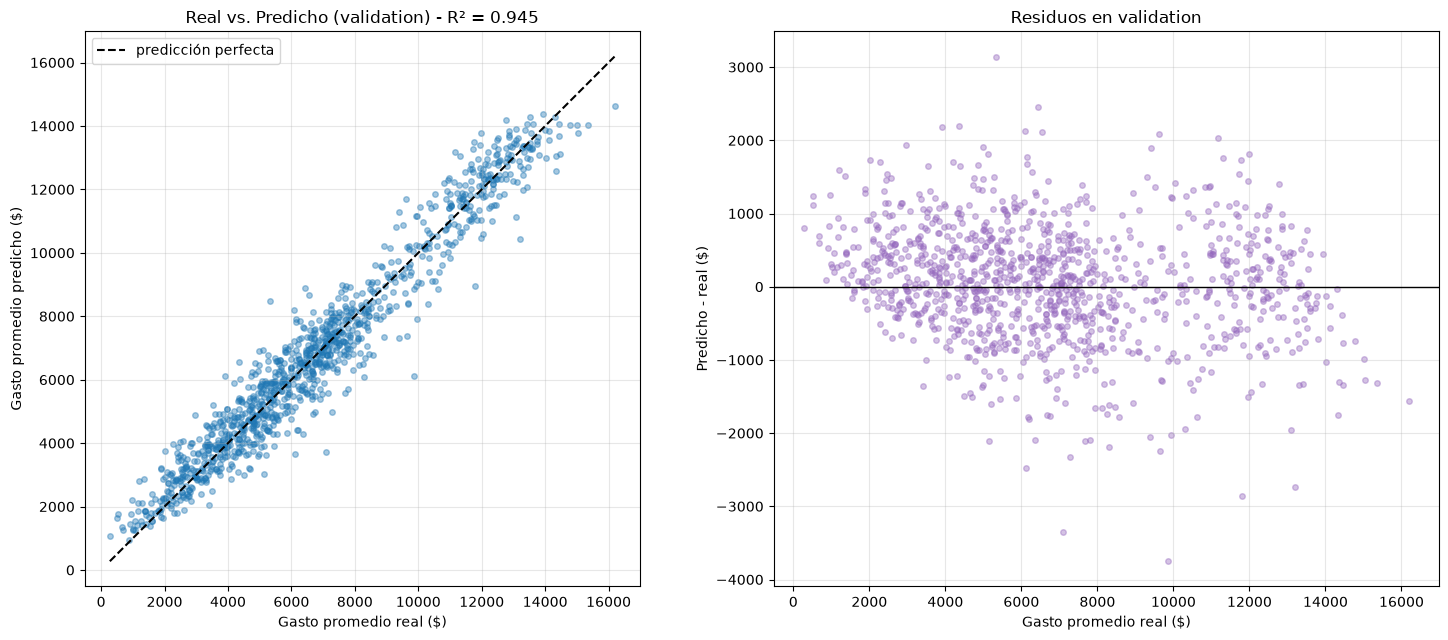

Error por quintil del gasto real (validation):
                               clientes    MAE  sesgo_medio
(275.27200000000005, 3829.92]       223  518.0        334.0
(3829.92, 5460.805]                 223  593.0         84.0
(5460.805, 7101.745]                223  616.0         31.0
(7101.745, 10052.546]               223  634.0       -179.0
(10052.546, 16187.5]                223  624.0        -29.0


In [35]:
def predecir_en_pesos(X):
    with torch.no_grad():
        return y_scaler.inverse_transform(modelo(X).cpu().numpy())

filas = []
for nombre, X, y_real in [("train", Xtr, y_train_np), ("validation", Xva, y_val_np), ("test", Xte, y_test_np)]:
    pred = predecir_en_pesos(X)
    filas.append({"Conjunto": nombre, "R²": r2_score(y_real, pred), "MAE ($)": mean_absolute_error(y_real, pred),
                  "RMSE ($)": np.sqrt(mean_squared_error(y_real, pred)), "Desvío del target ($)": y_real.std()})
tabla_final = pd.DataFrame(filas).round(4)
display(tabla_final)

val_pred = predecir_en_pesos(Xva).ravel()
val_real = y_val_np.ravel()
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
lims = [min(val_real.min(), val_pred.min()), max(val_real.max(), val_pred.max())]
axes[0].scatter(val_real, val_pred, alpha=0.4, s=16, color="tab:blue")
axes[0].plot(lims, lims, color="black", ls="--", lw=1.5, label="predicción perfecta")
axes[0].set_xlabel("Gasto promedio real ($)"); axes[0].set_ylabel("Gasto promedio predicho ($)")
axes[0].set_title(f"Real vs. Predicho (validation) - R² = {r2_score(val_real, val_pred):.3f}")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_aspect("equal")

residuos = val_pred - val_real
axes[1].scatter(val_real, residuos, alpha=0.4, s=16, color="tab:purple")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("Gasto promedio real ($)"); axes[1].set_ylabel("Predicho - real ($)")
axes[1].set_title("Residuos en validation"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

tramos = pd.qcut(val_real, 5)
print("Error por quintil del gasto real (validation):")
print(pd.DataFrame({"real": val_real, "abs_err": np.abs(residuos), "err": residuos}).groupby(tramos, observed=True)
      .agg(clientes=("real", "size"), MAE=("abs_err", "mean"), sesgo_medio=("err", "mean")).round(0))

In [36]:
# ¿Qué tan estable es el resultado final? Repetimos el entrenamiento completo con las 3 semillas
filas = []
for s in SEEDS:
    modelo_s, _, mejor_s = entrenar(CONFIG, EPOCHS_FINAL, s, guardar_mejor=True)
    modelo_s.load_state_dict(mejor_s["estado"]); modelo_s.eval()
    with torch.no_grad():
        pred_va = y_scaler.inverse_transform(modelo_s(Xva).cpu().numpy())
        pred_te = y_scaler.inverse_transform(modelo_s(Xte).cpu().numpy())
    filas.append({"Semilla": s, "Mejor época": mejor_s["epoca"],
                  "R² validation": r2_score(y_val_np, pred_va), "R² test": r2_score(y_test_np, pred_te)})
estabilidad = pd.DataFrame(filas)
display(estabilidad.round(4))
print(f"R² test: media = {estabilidad['R² test'].mean():.4f} | desvío = {estabilidad['R² test'].std():.4f}")

,Semilla,Mejor época,R² validation,R² test
0,0,49,0.9452,0.9404
1,1,51,0.9446,0.9411
2,2,65,0.9454,0.9416


R² test: media = 0.9411 | desvío = 0.0006


### Resultados

**Curvas de aprendizaje.** Train y validation bajan juntas y se mantienen muy cerca durante todo el entrenamiento. A partir de la época ≈50 el costo de train sigue bajando despacio mientras el de validation se estanca y empieza a subir, y el R² de validación cae de 0,945 a 0,939 en la época 150. Es el patrón de sobreajuste de la clase 4, bastante más suave que con learning rates más grandes, y es lo que justifica quedarse con la mejor época: el modelo final usa los pesos de la **época 49**.

**Métricas del modelo final (semilla 0):**

| Conjunto | R² | MAE | RMSE |
|---|---|---|---|
| Train | 0,947 | \$594 | \$761 |
| Validation | **0,945** | \$597 | \$779 |
| Test | **0,940** | \$624 | \$789 |

- **Supera ampliamente el R² ≥ 0,70 pedido.** El error típico ronda los \$600–790, alrededor de un cuarto del desvío del target (≈\$3.300), sobre un gasto promedio de \$6.750.
- **La brecha entre train y validation es de 0,002**, lo que en la clase 4 se describe como un buen ajuste, con la salvedad de que es sobre esta partición.
- **Repitiendo el entrenamiento con 3 semillas**, el R² de test da 0,9411 en promedio con un desvío de 0,0006. Eso mide la sensibilidad a la inicialización y al barajado con este mismo split; no es un intervalo de confianza sobre clientes futuros.
- **Test** queda apenas por debajo de validation (0,940 contra 0,945). No se usó para ajustar pesos, escaladores, hiperparámetros ni la época elegida: se evalúa recién en esta sección final. Como validation sí se usó dos veces (elegir hiperparámetros y elegir la época), **el número honesto para reportar es el de test**.

**Real vs. predicho y residuos.** Los puntos se concentran sobre la diagonal en todo el rango. La tabla por quintiles muestra el sesgo típico de regresión hacia la media, aunque suave: al quintil que menos gasta le predice de más (+\$334) y al cuarto quintil de menos (−\$179); el quintil más alto queda casi sin sesgo (−\$29). Los errores más grandes corresponden a clientes cuyo gasto no se explica solo con el mix de categorías, por ejemplo porque dentro de una categoría eligen productos más caros o más baratos que el promedio.

**MLP vs. regresión lineal.** Con las mismas features, la regresión lineal da 0,940 en validation y el MLP 0,945. La red mejora, pero poco, y es coherente con lo que anticipamos en 2a: el gasto promedio es casi una combinación lineal de las proporciones por categoría. Casi todo el trabajo lo hizo el feature engineering, no la no linealidad de la red.

### Proceso de iteración

1. **EDA a nivel transacción.** Ahí apareció el hallazgo que ordenó todo: el precio lo fija el producto. Eso nos llevó a describir a cada cliente por su mix de categorías.
2. **Diagnóstico de dependencia del volumen**, que nos hizo descartar los contadores y también la entropía y la concentración, que a primera vista parecían descriptores de perfil.
3. **Baselines lineales** para elegir entre conteos y proporciones, decidir sobre las subcategorías y medir el efecto del leakage antes de entrenar la red.
4. **Búsqueda por etapas** con 3 semillas, un factor por vez, con la regla del umbral declarada de antemano.
5. **Elección de la época,** a partir de la curva de 150 épocas, restaurando el mejor checkpoint.
6. **Evaluación final** en validation y en test, incluido el chequeo de estabilidad entre semillas. Test no participó de ninguna decisión: recién se mira acá.

### Qué pasaría con un cliente que recién empieza

El objetivo menciona que el modelo se usaría con clientes relativamente nuevos, de 3 a 5 compras. Nuestras features no dependen de la cantidad de compras, pero sí se estiman con ellas: con pocas transacciones, las proporciones son una versión ruidosa del mix real del cliente. Para medir cuánto importa eso, evaluamos el **mismo modelo ya entrenado** sobre los clientes de validation, pero calculando sus proporciones con solo $k$ transacciones al azar. El target sigue siendo el gasto promedio real del cliente.

In [37]:
filas = []
for k in [3, 5, 10, 20, None]:
    if k is None:
        X_eval = datos_clientes.loc[ids_val, feature_cols]
    else:
        muestra_k = df.sample(frac=1.0, random_state=1).groupby("User_ID", sort=False).head(k)
        X_eval = demografia.join(features_comportamiento(muestra_k)).reindex(columns=feature_cols).loc[ids_val]
    pred_k = predecir_en_pesos(a_tensor(x_scaler.transform(X_eval.values.astype(np.float32))))
    filas.append({"Compras conocidas del cliente": "todas (24,6 en promedio)" if k is None else f"hasta {k}",
                  "R² validation": r2_score(y_val_np, pred_k),
                  "MAE ($)": mean_absolute_error(y_val_np, pred_k),
                  "Sesgo medio ($)": float(np.mean(pred_k.ravel() - y_val_np.ravel()))})
escenarios = pd.DataFrame(filas)
display(escenarios.round(3))

,Compras conocidas del cliente,R² validation,MAE ($),Sesgo medio ($)
0,hasta 3,0.185,2317.581,-290.652
1,hasta 5,0.446,1914.092,-179.275
2,hasta 10,0.744,1282.580,-106.512
3,hasta 20,0.892,815.573,7.641
4,"todas (24,6 en promedio)",0.945,597.144,48.206


El resultado es contundente y conviene no maquillarlo:

| Compras conocidas | 3 | 5 | 10 | 20 | todas |
|---|---|---|---|---|---|
| R² validation | 0,19 | 0,45 | 0,74 | 0,89 | **0,945** |
| MAE | \$2.318 | \$1.914 | \$1.283 | \$816 | \$597 |
| Sesgo medio | −\$291 | −\$179 | −\$107 | +\$8 | +\$48 |

**Con 3 a 5 compras conocidas el modelo queda muy por debajo del 0,70 pedido.** Recién con unas 10 compras lo supera (0,744).

Esto no contradice lo que hicimos en 2a, pero sí lo completa. La columna de sesgo medio agrega información: con 3 compras el modelo subestima en promedio \$291, con 5 subestima \$179, y con el historial completo el sesgo es de apenas \$48. Hay un corrimiento hacia abajo cuando se conocen pocas compras, pero los errores individuales (MAE de \$2.318) son casi ocho veces más grandes que ese corrimiento. La explicación es que **las proporciones calculadas con pocas compras son mucho más variables**: con 3 compras, la proporción de cada categoría solo puede valer 0, 1/3, 2/3 o 1, así que el mix estimado es una caricatura del real.

Dicho de otro modo: el modelo aprendió bien la relación entre mix de compras y gasto, pero para aprovecharla hace falta conocer el mix con cierta precisión, y eso requiere una cantidad mínima de compras. Una forma razonable de mejorar este escenario, que dejamos planteada, sería entrenar con features remuestreadas (calcular las proporciones de cada cliente con k compras al azar y usar varias muestras por cliente), para que la red aprenda a trabajar con proporciones ruidosas.

---

### Extra: embeddings de `Product_ID` (contenido de la clase 4)

En la tabla de encodings descartamos `Product_ID` como feature: tiene 2.455 valores, así que one-hot generaría muchísimas columnas y un label encoding inventaría un orden. La clase 4 da la respuesta para justamente este caso: un **embedding**, es decir, una tabla de vectores aprendidos, uno por producto, que la red ajusta durante el entrenamiento.

Lo probamos como modelo alternativo. A cada cliente lo representamos por el **promedio de los embeddings de los productos que compró** (`nn.EmbeddingBag` con `mode="mean"`, que es la versión eficiente de "buscar los vectores y promediarlos"), concatenado con sus 6 variables demográficas. De ahí en adelante, la misma cabeza MLP de la configuración final.

Hay un punto importante que conecta con 2a. Ahí mostramos que usar el **precio medio de cada producto calculado sobre todo el dataset** lleva el R² a 1,000 y es leakage, porque usa los montos de los clientes de validation y test. Un embedding es la versión legítima de esa misma idea: los vectores se aprenden **solo con los clientes de train**; validation se usa para elegir la época y la dimensión, y test no interviene en nada. La diferencia no está en la información que se usa sino en de dónde sale.

In [38]:
# Índice de productos y matriz de compras por cliente (rellenada con un índice de padding)
productos = sorted(df["Product_ID"].unique())
prod_a_idx = {p: i for i, p in enumerate(productos)}
PAD = len(productos)                      # índice reservado: EmbeddingBag lo ignora en el promedio
MAX_COMPRAS = int(df.groupby("User_ID").size().max())
fila_de = {u: k for k, u in enumerate(datos_clientes.index)}

prod_train = set(df.loc[df["User_ID"].isin(set(ids_train)), "Product_ID"])
fuera_val = set(df.loc[df["User_ID"].isin(set(ids_val)), "Product_ID"]) - prod_train
fuera_test = set(df.loc[df["User_ID"].isin(set(ids_test)), "Product_ID"]) - prod_train
print(f"Productos distintos: {len(productos)} | vistos en train: {len(prod_train)}")
print(f"Comprados en validation pero nunca en train: {len(fuera_val)} | ídem en test: {len(fuera_test)}")

def matriz_productos(transacciones):
    m = np.full((len(datos_clientes), MAX_COMPRAS), PAD, dtype=np.int64)
    for uid, g in transacciones.groupby("User_ID"):
        idx = [prod_a_idx[p] for p in g["Product_ID"]]
        m[fila_de[uid], :len(idx)] = idx
    return m

MAT = matriz_productos(df)
demo_scaler = StandardScaler().fit(demografia.loc[ids_train].values)

def datos_emb(ids_, mat=MAT):
    filas = [fila_de[u] for u in ids_]
    return (torch.tensor(mat[filas], dtype=torch.long, device=device),
            a_tensor(demo_scaler.transform(demografia.loc[ids_].values)))

Ptr, Btr = datos_emb(ids_train); Pva, Bva = datos_emb(ids_val); Pte, Bte = datos_emb(ids_test)
print("Matriz de productos por cliente:", tuple(Ptr.shape), "| demográficas:", tuple(Btr.shape))

Productos distintos: 2455 | vistos en train: 2455
Comprados en validation pero nunca en train: 0 | ídem en test: 0


Matriz de productos por cliente: (5202, 50) | demográficas: (5202, 6)


In [39]:
class RedConEmbeddings(nn.Module):
    def __init__(self, n_productos, dim_emb, n_demo, capas, activacion):
        super().__init__()
        self.emb = nn.EmbeddingBag(n_productos, dim_emb, mode="mean", padding_idx=PAD)
        nn.init.normal_(self.emb.weight, std=0.05)
        capas_l, prev = [], dim_emb + n_demo
        for h in capas:
            capas_l += [nn.Linear(prev, h), ACTIVACIONES[activacion]()]
            prev = h
        self.mlp = nn.Sequential(*capas_l, nn.Linear(prev, 1))

    def forward(self, idx_productos, demo):
        return self.mlp(torch.cat([self.emb(idx_productos), demo], dim=1))

def entrenar_emb(dim_emb, seed, epochs=120):
    torch.manual_seed(seed)
    modelo = RedConEmbeddings(PAD + 1, dim_emb, Btr.shape[1], CONFIG["capas"], CONFIG["activacion"]).to(device)
    opt = crear_optimizador(CONFIG["optimizador"], modelo.parameters(), CONFIG["lr"], CONFIG["weight_decay"])
    perdida = PERDIDAS[CONFIG["perdida"]]()
    loader = DataLoader(TensorDataset(Ptr, Btr, ytr), batch_size=CONFIG["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    mejor = {"val_r2": -np.inf, "epoca": 0, "estado": None}
    for epoca in range(epochs):
        modelo.train()
        for pb, bb, yb in loader:
            opt.zero_grad(); perdida(modelo(pb, bb), yb).backward(); opt.step()
        modelo.eval()
        with torch.no_grad():
            r2 = r2_score(y_val_np, y_scaler.inverse_transform(modelo(Pva, Bva).cpu().numpy()))
        if r2 > mejor["val_r2"]:
            mejor.update(val_r2=r2, epoca=epoca + 1, estado=copy.deepcopy(modelo.state_dict()))
    modelo.load_state_dict(mejor["estado"]); modelo.eval()
    return modelo, mejor

modelos_emb, filas = {}, []
for dim_emb in [4, 8]:
    for s in SEEDS[:2]:
        modelo_s, mejor_s = entrenar_emb(dim_emb, s)
        modelos_emb[(dim_emb, s)] = modelo_s
        with torch.no_grad():
            pred_te = y_scaler.inverse_transform(modelo_s(Pte, Bte).cpu().numpy())
        filas.append({"dim del embedding": dim_emb, "semilla": s, "mejor época": mejor_s["epoca"],
                      "R² validation": mejor_s["val_r2"], "R² test": r2_score(y_test_np, pred_te),
                      "MAE test ($)": mean_absolute_error(y_test_np, pred_te)})
tabla_emb = pd.DataFrame(filas)
display(tabla_emb.round(4))

# Elegimos la dimensión por el R² medio de VALIDATION (no de test) y la primera semilla como corrida ilustrativa
DIM_EMB = int(tabla_emb.groupby("dim del embedding")["R² validation"].mean().idxmax())
SEMILLA_EMB = SEEDS[0]
modelo_emb = modelos_emb[(DIM_EMB, SEMILLA_EMB)]
fila_elegida = tabla_emb.query("`dim del embedding` == @DIM_EMB and semilla == @SEMILLA_EMB").iloc[0]
print(f"Modelo analizado en el resto de la sección: dimensión {DIM_EMB}, semilla {SEMILLA_EMB} "
      f"(R² val = {fila_elegida['R² validation']:.4f}, R² test = {fila_elegida['R² test']:.4f}, MAE test = ${fila_elegida['MAE test ($)']:.0f})")

,dim del embedding,semilla,mejor época,R² validation,R² test,MAE test ($)
0,4,0,114,0.9999,0.9999,26.4212
1,4,1,110,0.9999,0.9999,27.7558
2,8,0,114,0.9998,0.9998,33.1279
3,8,1,94,0.9998,0.9998,31.3488


Modelo analizado en el resto de la sección: dimensión 4, semilla 0 (R² val = 0.9999, R² test = 0.9999, MAE test = $26)


Correlación entre el precio que le atribuye la red a cada producto y su precio real: 0.9835
Error absoluto medio de ese precio implícito: $417

Precio implícito por tramo de precio real:


,productos,precio_real_medio,precio_estimado_medio
tramo,,,
"(0, 1000]",1063,347.0,334.0
"(1000, 5000]",407,2692.0,2583.0
"(5000, 10000]",477,7810.0,7845.0
"(10000, 15000]",318,11654.0,11774.0
"(15000, 20000]",57,17646.0,17230.0
"(20000, 25000]",60,22369.0,19112.0
"(25000, 31000]",73,27318.0,19663.0


Precio implícito máximo que produce la red: $19,782 | precio real máximo: $29,980
Gasto promedio más alto entre los clientes de train: $17,231


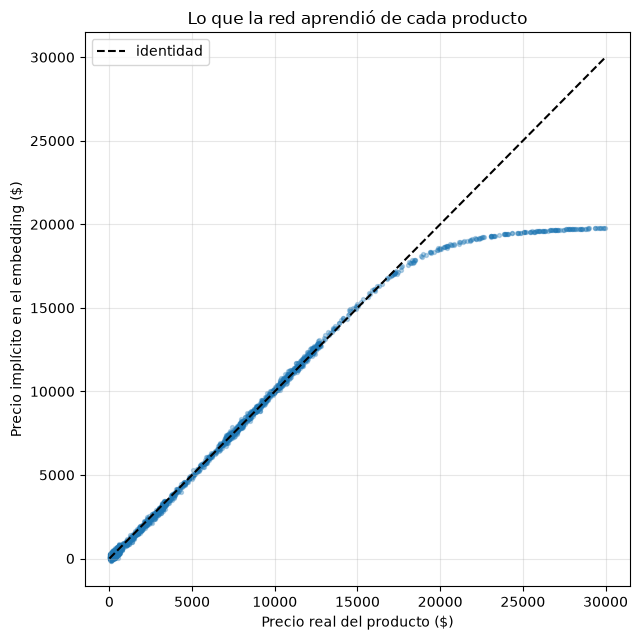

In [40]:
# ¿Qué aprendió el embedding? Le preguntamos al modelo por un cliente ficticio que compró un solo producto
precio_real = df.groupby("Product_ID")["Purchase"].mean().reindex(productos).values
uno_solo = np.full((len(productos), MAX_COMPRAS), PAD, dtype=np.int64)
uno_solo[np.arange(len(productos)), 0] = np.arange(len(productos))
demo_promedio = np.tile(demo_scaler.transform(demografia.loc[ids_train].values).mean(axis=0), (len(productos), 1))
with torch.no_grad():
    precio_estimado = y_scaler.inverse_transform(
        modelo_emb(torch.tensor(uno_solo, dtype=torch.long, device=device), a_tensor(demo_promedio)).cpu().numpy()).ravel()

print(f"Correlación entre el precio que le atribuye la red a cada producto y su precio real: {np.corrcoef(precio_estimado, precio_real)[0, 1]:.4f}")
print(f"Error absoluto medio de ese precio implícito: ${np.abs(precio_estimado - precio_real).mean():,.0f}")

tramos = pd.cut(precio_real, [0, 1000, 5000, 10000, 15000, 20000, 25000, 31000])
resumen_precio = pd.DataFrame({"real": precio_real, "estimado": precio_estimado, "tramo": tramos}).groupby("tramo", observed=True).agg(
    productos=("real", "size"), precio_real_medio=("real", "mean"), precio_estimado_medio=("estimado", "mean")).round(0)
print("\nPrecio implícito por tramo de precio real:")
display(resumen_precio)
print(f"Precio implícito máximo que produce la red: ${precio_estimado.max():,.0f} | precio real máximo: ${precio_real.max():,.0f}")
print(f"Gasto promedio más alto entre los clientes de train: ${y_train_np.max():,.0f}")

plt.figure(figsize=(6.5, 6.5))
plt.scatter(precio_real, precio_estimado, s=8, alpha=0.3)
lim = [0, max(precio_real.max(), precio_estimado.max())]
plt.plot(lim, lim, "k--", lw=1.5, label="identidad")
plt.xlabel("Precio real del producto ($)"); plt.ylabel("Precio implícito en el embedding ($)")
plt.title("Lo que la red aprendió de cada producto"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [41]:
# El mismo escenario de pocas compras, ahora con el modelo de embeddings
filas = []
for k in [3, 5, 10, 20, None]:
    mat_k = MAT if k is None else matriz_productos(df.sample(frac=1.0, random_state=1).groupby("User_ID", sort=False).head(k))
    Pk, Bk = datos_emb(ids_val, mat_k)
    with torch.no_grad():
        pred_k = y_scaler.inverse_transform(modelo_emb(Pk, Bk).cpu().numpy())
    filas.append({"Compras conocidas del cliente": "todas (24,6 en promedio)" if k is None else f"hasta {k}",
                  "R² validation (embeddings)": r2_score(y_val_np, pred_k),
                  "MAE ($)": mean_absolute_error(y_val_np, pred_k)})
comparacion = pd.DataFrame(filas).merge(
    escenarios.rename(columns={"R² validation": "R² validation (modelo principal)"})[
        ["Compras conocidas del cliente", "R² validation (modelo principal)"]],
    on="Compras conocidas del cliente")
display(comparacion.round(3))

,Compras conocidas del cliente,R² validation (embeddings),MAE ($),R² validation (modelo principal)
0,hasta 3,-0.227,2916.470,0.185
1,hasta 5,0.296,2209.567,0.446
2,hasta 10,0.765,1173.305,0.744
3,hasta 20,0.940,406.252,0.892
4,"todas (24,6 en promedio)",1.000,26.435,0.945


**El resultado es casi perfecto.** El modelo que analizamos (dimensión 4, semilla 0, elegido por el R² medio de validation) llega a **R² = 0,9999 en validation y en test**, con un MAE de \$26 contra los \$624 del modelo principal. Con dimensión 8 no mejora. Los 2.455 productos aparecen en train, así que ningún cliente de validation o test trae productos con embedding sin entrenar.

**¿Qué aprendió?** Para averiguarlo le preguntamos a la red por un cliente ficticio que compró un solo producto, con demografía promedio. La respuesta correlaciona **0,984** con el precio real de ese producto, lo que indica que la representación aprendida carga información de precios. Pero el diagnóstico también muestra su límite: el precio implícito **se satura alrededor de \$19.800**, mientras que los precios reales llegan a \$29.980. Para los 73 productos de más de \$25.000 la red responde ≈\$19.700 en promedio, y eso se ve en el gráfico como el achatamiento de la nube en el extremo derecho.

La explicación es que le estamos pidiendo algo que nunca vio: el modelo fue entrenado para predecir **promedios de clientes**, y el cliente de train que más gasta promedia \$17.231. Un cliente con una sola compra de \$28.000 está fuera de ese rango, y además tiene 1 compra cuando en entrenamiento todos tienen entre 10 y 50. Así que el diagnóstico sirve para mostrar que la red ordenó los productos por precio, no para afirmar que recuperó el precio exacto de cada uno.

**Esto no es leakage, y la diferencia importa.** En 2a mostramos que agregar el precio medio de los productos calculado sobre todo el dataset lleva el R² a 1,000, y eso sí es trampa, porque ese promedio se calcula con las transacciones de los clientes de validation y test. Acá los gradientes se calculan **solo con los 5.202 clientes de train**; validation interviene únicamente para elegir la época y la dimensión del embedding, que es el uso normal de un conjunto de validación, y test no interviene en nada. La lección es que no alcanza con preguntarse *qué* información usa una feature: importa de dónde sale y si va a estar disponible al momento de predecir.

**Pero no es un mejor modelo para el problema de negocio.** Cuando lo evaluamos conociendo pocas compras, el resultado se da vuelta:

| Compras conocidas | 3 | 5 | 10 | 20 | todas |
|---|---|---|---|---|---|
| R² con embeddings | **−0,23** | **0,30** | 0,77 | 0,94 | 1,00 |
| R² modelo principal | 0,19 | 0,45 | 0,74 | 0,89 | 0,95 |

Con 3 a 5 compras conocidas el modelo de embeddings rinde **peor que el de proporciones**, y con 3 queda incluso por debajo de la referencia constante de este experimento (un R² negativo significa que predice peor que usar el promedio de los clientes evaluados). La razón es que apuesta todo a la canasta exacta: si conoce los productos, clava el promedio; si solo conoce tres tomados al azar, su predicción queda atada al precio de esos tres, o sea que es muy sensible a qué productos entraron en la muestra. El modelo de proporciones trabaja con una descripción más gruesa, en qué categorías compra el cliente, que resiste mejor tener pocos datos. Con 10 o más compras los embeddings pasan al frente.

**Conclusión de esta sección.** Conocido el historial completo, el problema deja de ser de modelado y pasa a ser casi aritmética, y los embeddings lo llevan al límite (el 1,000 de la última tabla es el mismo 0,9999 redondeado a tres decimales, con un MAE de \$26 en validation). El modelado real aparece cuando hay poca información del cliente, y ahí conviene una representación más agregada. Por eso mantenemos el modelo de proporciones como respuesta principal y dejamos esta variante como lo que es: una demostración de que los embeddings de la clase 4 resuelven bien las variables categóricas de alta cardinalidad, y de por dónde pasa el límite entre una representación aprendida y el leakage.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.

### Conclusiones finales

**¿Se cumplió el objetivo? Sí, con una salvedad importante.** El modelo estima el gasto promedio de cada cliente con R² = 0,940 en test (0,9411 ± 0,0006 sobre 3 semillas) y un error absoluto medio de \$624 sobre un gasto promedio de ≈\$6.750. Está muy por encima del 0,70 pedido y no usa ninguna variable que dependa de cuántas compras acumuló el cliente. La salvedad es la de la sección anterior: ese rendimiento se logra conociendo el historial completo, y cae a 0,45 si solo se conocen 5 compras.

**Lo más importante que aprendimos:**

1. **El gasto de un cliente depende de qué compra, no de quién es.** Cada producto tiene un precio fijo y las categorías tienen niveles de precio muy distintos (de \$330 a \$22.000). Por eso el mix de categorías explica casi todo el gasto promedio, mientras que las variables demográficas solas llegan a R² ≈ 0,28.
2. **No alcanza con que una feature "no use el target" para que sea válida.** La entropía del mix y la proporción de la categoría favorita no tocan `Purchase`, pero al estimarlas con pocas compras se deforman (la entropía cae de 0,76 a 0,47) porque en el fondo son proxies de la cantidad de transacciones. Las proporciones, en cambio, mantienen su valor esperado. Descartar las que dependían del volumen costó apenas 0,0006 de R².
3. **Insesgado no es lo mismo que preciso.** Las proporciones son insesgadas bajo este muestreo, pero eso no se traslada automáticamente a las predicciones: con 3 compras conocidas el modelo subestima en promedio \$291. Aun así, el problema dominante no es ese corrimiento sino el ruido, porque el MAE en ese escenario es de \$2.318, casi ocho veces mayor.
4. **El leakage está muy cerca.** Tres features que parecen razonables se calculan con `Purchase` y inflan el resultado: el gasto total lleva el R² a 0,947, la proporción de gasto por categoría a 0,956 y el precio medio de los productos comprados directamente a 1,000. La diferencia entre "proporción de compras" y "proporción de gasto" en una categoría parece un detalle, pero una es legítima y la otra filtra el target.
5. **Casi ninguna decisión de la red movió la aguja.** Con las mismas features, la regresión lineal da 0,940 y el MLP 0,945. Las siete etapas de búsqueda se movieron en el tercer o cuarto decimal, y en cuatro de ellas la mejora ni siquiera superó el ruido entre semillas, así que la regla del umbral nos devolvió a la configuración de referencia de la clase. Solo la activación (sigmoid, +0,0020) y la arquitectura (`[128, 64, 32]`, +0,0015) ganaron por encima del ruido. Es un resultado en sí mismo: en un problema casi lineal, el feature engineering define el techo y el ajuste fino de la red aporta poco.
6. **Los embeddings de la clase 4 resuelven la alta cardinalidad, pero no el problema de negocio.** Representar a cada cliente por el promedio de los embeddings de los productos que compró lleva el R² a 0,9999, porque la representación aprendida carga información del precio de cada producto (correlación 0,984, aunque subestima los más caros). Es legítimo, porque los embeddings se entrenan solo con train, a diferencia del precio medio calculado sobre todo el dataset, que sí es leakage. Pero con 3 a 5 compras conocidas ese modelo rinde **peor** que el de proporciones, porque depende de la canasta exacta.

**Limitaciones:**

- **El planteo es casi una identidad contable.** Como el precio lo fija el producto, si se conocen todas las compras de un cliente el gasto promedio se puede calcular directamente, sin modelo. El valor real del modelo aparece justamente en el régimen de pocas compras, que es donde peor anda. Esto es una característica del caso de estudio, no algo que se resuelva con otra arquitectura.
- **Estructura sintética.** La cantidad de transacciones por cliente tiene huecos (nadie tiene entre 21 y 29) y grupos con gasto muy distinto. No usamos esa variable, pero puede haber quedado reflejada indirectamente en las proporciones, que correlacionan 0,22 en promedio con el volumen.
- **`Stay_In_Current_City_Years` es un proxy parcial de antigüedad** (correlación 0,43 con la cantidad de transacciones). La dejamos porque es un dato disponible en el momento de predecir y porque empíricamente no cambia el resultado, pero es la feature que menos encaja con el criterio que aplicamos al resto.
- **Validation se usó dos veces** (elegir hiperparámetros y elegir la época), así que su R² está algo optimista. Por eso reportamos test como número final.
- **Para predecir sobre un cliente nuevo de a uno** habría que fijar las columnas de categorías y de one-hot aprendidas en entrenamiento y completar con ceros las que ese cliente no tenga: `crosstab` y `get_dummies` generan columnas según lo que aparece en los datos de entrada. En la evaluación actual no se nota porque procesamos miles de clientes juntos.
- **Variación de precios dentro de una categoría** (sobre todo la 3, con desvío \$9.500). Las proporciones no la capturan y ahí están los errores más grandes. Una forma legítima de incorporarla sería usar información del producto que no dependa del monto, como las subcategorías, que descartamos por parsimonia.

---

## Referencias

**Material de la materia**
- Clase 1: introducción, neurona, forward pass y conteo de parámetros.
- Clase 2: backpropagation, funciones de activación, funciones de costo y optimizadores (`clase2_1_backpropagation`, `clase2_2_funciones_activacion`, `clase2_3_funciones_costo`, `clase2_4_optimizadores`).
- Clase 3: PyTorch, `nn.Sequential`, `TensorDataset`/`DataLoader`, baseline lineal y R² (`clase3_1_intro_pytorch`).
- Clase 4: curvas de aprendizaje, Dropout y L2 (`clase_4_1_dropout`); `weight_decay` en Adam aparece en el material adicional `Clase4_Embeddings`.

**Bibliografía externa**
- Kingma, D. P. y Ba, J. (2015). *Adam: A Method for Stochastic Optimization*. ICLR. (Algoritmo 1 y §2.1; PDF en el material adicional de la clase 2.) Lo usamos para implementar Adam desde cero en 1b.
- Ruder, S. (2016). *An overview of gradient descent optimization algorithms*. arXiv:1609.04747. (§2 batch/mini-batch, §4 métodos adaptativos, §6.3 early stopping; PDF en el material adicional de la clase 2.)
- Reddi, S., Kale, S. y Kumar, S. (2018). *On the Convergence of Adam and Beyond*. ICLR. (PDF en el material adicional de la clase 2.) Lo tuvimos en cuenta para no presentar a Adam como universalmente superior.
- Huber, P. J. (1964). *Robust Estimation of a Location Parameter*. Annals of Mathematical Statistics 35(1), 73–101. La comparamos contra MSE y MAE en la etapa 4 usando [`torch.nn.HuberLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.HuberLoss.html) (tramo cuadrático para errores menores a δ y lineal para los mayores, con δ=1 por defecto); el modelo final usa MSE.
- Embeddings: notebooks `clase_4_1_embeddings` y `Clase4_Embeddings` de la clase 4 (allí se usa `nn.Embedding`; nosotros adaptamos la idea con [`torch.nn.EmbeddingBag`](https://docs.pytorch.org/docs/stable/generated/torch.nn.EmbeddingBag.html), que promedia los vectores de varios ítems en una sola operación).
- Guardado y restauración de pesos con `state_dict`: [Saving and Loading Models, documentación de PyTorch](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html).
- Shannon, C. E. (1948). *A Mathematical Theory of Communication*. Usamos la entropía de esa definición como medida de diversidad del mix de categorías (no confundir con la entropía cruzada usada como función de costo en clasificación).